## Deep Learning Ensemble + Automatic Data Filtering (Option C)

Create a two-pass deep learning pipeline that stays close to the original `03b` notebook structure:

1. **Pass 1 — Out-of-fold filtering**
   - train 5 fine-tuned CNN backbones with 5-fold stratified splits
   - collect per-image out-of-fold probabilities, agreement/disagreement, confident-wrong signals, and image-quality features
   - assign each training image one of: **keep**, **downweight**, **remove**

2. **Pass 2 — Final cleaned ensemble**
   - retrain the same 5 models on the cleaned / weighted dataset
   - average their probabilities on the Kaggle test set
   - save submission + detailed diagnostics

This notebook intentionally mirrors the original Option C notebook style:
- device setup
- full dataset loading
- helper functions
- training loop
- internal evaluation / diagnostics
- error visualization
- model + metrics saving
- Kaggle submission generation

In [2]:
from pathlib import Path
import sys

# Add project root so src imports work when running from notebooks/.
sys.path.append(str(Path().resolve().parent))

from src.config import (
    PART1_KAGGLE_DIR,
    PART1_TRAIN_DIR,
    PART1_TEST_DIR,
)

assert PART1_TRAIN_DIR.exists(), f"Training data missing: {PART1_TRAIN_DIR}"
assert PART1_TEST_DIR.exists(), f"Test data missing: {PART1_TEST_DIR}"

print("Data paths validated:")
print(f"- Part 1 root : {PART1_KAGGLE_DIR}")
print(f"- Train       : {PART1_TRAIN_DIR}")
print(f"- Test        : {PART1_TEST_DIR}")

Data paths validated:
- Part 1 root : /home/cotte/github/school/ecse415-final-project/data/part1/data/kaggle
- Train       : /home/cotte/github/school/ecse415-final-project/data/part1/data/kaggle/train/train
- Test        : /home/cotte/github/school/ecse415-final-project/data/part1/data/kaggle/test/test


### Imports & Device Setup
Import all required libraries, load project helpers, and configure GPU / dataloader settings.

In [3]:
import contextlib
import gc
import importlib
import json
import logging
import math
import os
import random
from collections import defaultdict
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models
from torchvision.transforms import v2 as T
from tqdm import tqdm

from src.config import (
    IMG_SIZE_CNN,
    CLASS_NAMES,
    FIGURES_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
)
import src.utils
importlib.reload(src.utils)
from src.utils import (
    load_labeled_images_memmap,
    load_test_images_memmap,
    generate_submission_csv,
)
from src.evaluation import compute_metrics, compute_confusion_matrix
from src.visualization import (
    plot_confusion_matrix,
    plot_training_history,
    plot_sample_predictions,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_CUDA = device.type == "cuda"
PIN_MEMORY = USE_CUDA

_nc = os.cpu_count() or 4
DATALOADER_WORKERS = min(4, max(0, _nc - 1)) if USE_CUDA else 0
PREFETCH_FACTOR = 4 if DATALOADER_WORKERS > 0 else None

# torch.compile uses symbolic shape tracing; sympy can emit noisy W0407 lines.
logging.getLogger("torch.utils._sympy").setLevel(logging.ERROR)

if USE_CUDA:
    print(f"Using device: {device}")
    print(f"CUDA (PyTorch build): {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
else:
    print(f"Using device: {device}")
    print("CUDA not available — CPU fallback.")

Using device: cuda
CUDA (PyTorch build): 13.0
GPU: NVIDIA GeForce RTX 5070 Ti


### Load Full Dataset
Load the full labeled Kaggle training set once.  
Pass 1 uses **5-fold stratified OOF training** on all labeled images.  
Pass 2 retrains all models on the cleaned / weighted dataset.

In [4]:
# Load the FULL dataset once (RGB)
X, y = load_labeled_images_memmap(
    img_size=IMG_SIZE_CNN, grayscale=False, max_samples=None, rebuild=False
)
print(f"Full dataset: {X.shape}, labels: {y.shape}")
print(f"  Class 0 (cat): {(y == 0).sum()},  Class 1 (dog): {(y == 1).sum()}")

SEED = 42
NUM_FOLDS = 5
BATCH_SIZE = 32
USE_AMP = USE_CUDA
# Set True to try torch.compile (faster; may still print sympy shape warnings on some builds).
USE_TORCH_COMPILE = False
# If True, Pass 1 skips training for a backbone when all five fold checkpoints exist on disk.
USE_CHECKPOINT = True
# If True, Pass 2 skips training when the final_clean checkpoint for that model exists.
USE_CHECKPOINT_PASS2 = True

# Pass 1 epochs (lighter but still meaningful)
NUM_EPOCHS_HEAD_PASS1 = 6
NUM_EPOCHS_FULL_PASS1 = 10

# Pass 2 epochs (final cleaned-data training)
NUM_EPOCHS_HEAD_PASS2 = 8
NUM_EPOCHS_FULL_PASS2 = 14

# Keep close to the user's planned 5-model ensemble
MODEL_SPECS = [
    {"name": "resnet50",        "input_size": 224, "weights_name": "ResNet50_Weights"},
    {"name": "convnext_tiny",   "input_size": 224, "weights_name": "ConvNeXt_Tiny_Weights"},
    {"name": "convnext_small",  "input_size": 224, "weights_name": "ConvNeXt_Small_Weights"},
    {"name": "efficientnet_b3", "input_size": 300, "weights_name": "EfficientNet_B3_Weights"},
    {"name": "efficientnet_b4", "input_size": 380, "weights_name": "EfficientNet_B4_Weights"},
]

# Conservative filtering policy — tune only after inspecting diagnostics.
REMOVE_WRONG_CONF = 0.90
REMOVE_DISAGREE_COUNT = 4          # 4/5 or 5/5 models disagree with the label
REMOVE_OPP_NEIGHBOR_FRAC = 0.80
REMOVE_SUSPICION_QUANTILE = 0.97
REMOVE_LOW_ENTROPY_QUANTILE = 0.02
REMOVE_LOW_BLUR_QUANTILE = 0.02

DOWNWEIGHT_TRUE_CONF = 0.75
DOWNWEIGHT_DISAGREE_COUNT = 2
DOWNWEIGHT_OPP_NEIGHBOR_FRAC = 0.50
DOWNWEIGHT_VALUE = 0.60

KEEP_VALUE = 1.00

PROJECT_TAG = "optionC_ensemble_filtered"

print(f"Pass 1: {NUM_FOLDS}-fold OOF over {len(y)} images")
print("Models:", [m["name"] for m in MODEL_SPECS])

Full dataset: (20000, 224, 224, 3), labels: (20000,)
  Class 0 (cat): 10021,  Class 1 (dog): 9979
Pass 1: 5-fold OOF over 20000 images
Models: ['resnet50', 'convnext_tiny', 'convnext_small', 'efficientnet_b3', 'efficientnet_b4']


### Helper Functions
Define:
- reproducibility helpers
- dataset / dataloader wrappers
- model factory
- training / evaluation loops
- prediction helpers
- embedding extraction
- image-quality features

In [5]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Per-batch tqdm during train/val/predict (epoch summaries still print each epoch).
SHOW_BATCH_BARS = False


def maybe_compile(m):
    if not USE_TORCH_COMPILE:
        return m
    try:
        return torch.compile(m, mode="default")
    except Exception as exc:
        print("torch.compile skipped:", exc)
        return m


def normalize_ckpt_state_dict(state):
    # Checkpoints saved under torch.compile use _orig_mod.* keys; strip for plain nn.Module load.
    keys = list(state.keys())
    if not keys:
        return state
    prefix = "_orig_mod."
    if not keys[0].startswith(prefix):
        return state
    out = {}
    for k, v in state.items():
        if k.startswith(prefix):
            out[k[len(prefix):]] = v
        else:
            out[k] = v
    return out


def make_transforms(img_size, train=True):
    if train:
        return T.Compose([
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
            T.RandomHorizontalFlip(),
            T.RandomRotation(15),
            T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.04),
            T.RandomResizedCrop((img_size, img_size), scale=(0.80, 1.0)),
            T.RandomErasing(p=0.10),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    return T.Compose([
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Resize((img_size, img_size)),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


class NumpyImageDataset(Dataset):
    def __init__(self, X, y=None, indices=None, transform=None, return_index=False):
        self.X = X
        self.y = y
        self.indices = np.arange(len(X), dtype=np.int64) if indices is None else np.asarray(indices)
        self.transform = transform
        self.return_index = return_index

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        ridx = int(self.indices[idx])
        # Memmap slices are read-only; torchvision needs a writable array for ToTensor.
        img = np.array(self.X[ridx], copy=True)
        if self.transform is not None:
            img = self.transform(img)
        if self.y is None:
            if self.return_index:
                return img, ridx
            return img
        label = int(self.y[ridx])
        if self.return_index:
            return img, label, ridx
        return img, label


def make_loader(X, y, indices, img_size, train, sample_weights=None, shuffle=True):
    ds = NumpyImageDataset(
        X, y, indices=indices, transform=make_transforms(img_size, train=train), return_index=True
    )

    loader_kw = dict(
        batch_size=BATCH_SIZE,
        num_workers=DATALOADER_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=DATALOADER_WORKERS > 0,
        prefetch_factor=PREFETCH_FACTOR if DATALOADER_WORKERS > 0 else None,
    )

    if train and sample_weights is not None:
        local_weights = torch.as_tensor(sample_weights[indices], dtype=torch.double)
        sampler = WeightedRandomSampler(local_weights, num_samples=len(local_weights), replacement=True)
        return DataLoader(ds, sampler=sampler, shuffle=False, **loader_kw)

    return DataLoader(ds, shuffle=(shuffle if train else False), **loader_kw)


def build_model(model_name, device):
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        n = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(0.30), nn.Linear(n, 2))

    elif model_name == "convnext_tiny":
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        n = model.classifier[2].in_features
        model.classifier[2] = nn.Sequential(nn.Dropout(0.30), nn.Linear(n, 2))

    elif model_name == "convnext_small":
        model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        n = model.classifier[2].in_features
        model.classifier[2] = nn.Sequential(nn.Dropout(0.30), nn.Linear(n, 2))

    elif model_name == "efficientnet_b3":
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        n = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(nn.Dropout(0.30), nn.Linear(n, 2))

    elif model_name == "efficientnet_b4":
        model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        n = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(nn.Dropout(0.30), nn.Linear(n, 2))

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    model = model.to(device)
    model = maybe_compile(model)
    return model


def get_head_parameters(model_name, model):
    if model_name == "resnet50":
        return model.fc.parameters()
    elif model_name.startswith("convnext"):
        return model.classifier.parameters()
    elif model_name.startswith("efficientnet"):
        return model.classifier.parameters()
    raise ValueError(model_name)


def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None, use_amp=False):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    nb = PIN_MEMORY and device.type == "cuda"
    amp_ctx = (
        torch.amp.autocast("cuda", enabled=True)
        if use_amp and device.type == "cuda"
        else contextlib.nullcontext()
    )

    train_it = tqdm(loader, desc="  Train", leave=False) if SHOW_BATCH_BARS else loader
    for images, labels, _ in train_it:
        images = images.to(device, non_blocking=nb)
        labels = labels.to(device, non_blocking=nb)

        optimizer.zero_grad(set_to_none=True)
        with amp_ctx:
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device, use_amp=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    nb = PIN_MEMORY and device.type == "cuda"
    amp_ctx = (
        torch.amp.autocast("cuda", enabled=True)
        if use_amp and device.type == "cuda"
        else contextlib.nullcontext()
    )

    val_it = tqdm(loader, desc="  Val  ", leave=False) if SHOW_BATCH_BARS else loader
    for images, labels, _ in val_it:
        images = images.to(device, non_blocking=nb)
        labels = labels.to(device, non_blocking=nb)
        with amp_ctx:
            outputs = model(images)
            loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def predict_probs(model, loader, device, use_amp=False):
    model.eval()
    nb = PIN_MEMORY and device.type == "cuda"
    amp_ctx = (
        torch.amp.autocast("cuda", enabled=True)
        if use_amp and device.type == "cuda"
        else contextlib.nullcontext()
    )

    all_probs = []
    all_labels = []
    all_indices = []

    pred_it = tqdm(loader, desc="  Predict", leave=False) if SHOW_BATCH_BARS else loader
    for batch in pred_it:
        if len(batch) == 3:
            images, labels, indices = batch
            all_labels.append(labels.numpy())
        else:
            images, indices = batch
        images = images.to(device, non_blocking=nb)
        with amp_ctx:
            outputs = torch.nan_to_num(model(images).float(), nan=0.0, posinf=0.0, neginf=0.0)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_indices.append(np.asarray(indices))

    probs = np.concatenate(all_probs, axis=0)
    indices = np.concatenate(all_indices, axis=0)
    labels = np.concatenate(all_labels, axis=0) if all_labels else None
    return probs, labels, indices


@torch.no_grad()
def extract_embeddings(model_name, model, loader, device, use_amp=False):
    model.eval()
    nb = PIN_MEMORY and device.type == "cuda"

    if model_name == "resnet50":
        feature_extractor = nn.Sequential(*(list(model.children())[:-1])).to(device)
    elif model_name.startswith("efficientnet"):
        feature_extractor = nn.Sequential(model.features, model.avgpool).to(device)
    elif model_name.startswith("convnext"):
        # convnext: features -> avgpool -> flatten
        class ConvNeXtFeature(nn.Module):
            def __init__(self, m):
                super().__init__()
                self.features = m.features
                self.avgpool = m.avgpool
            def forward(self, x):
                x = self.features(x)
                x = self.avgpool(x)
                return x
        feature_extractor = ConvNeXtFeature(model).to(device)
    else:
        raise ValueError(model_name)

    amp_ctx = (
        torch.amp.autocast("cuda", enabled=True)
        if use_amp and device.type == "cuda"
        else contextlib.nullcontext()
    )

    all_feats, all_indices = [], []
    emb_it = tqdm(loader, desc="  Embed", leave=False) if SHOW_BATCH_BARS else loader
    for batch in emb_it:
        if len(batch) == 3:
            images, _, indices = batch
        else:
            images, indices = batch
        images = images.to(device, non_blocking=nb)
        with amp_ctx:
            feats = feature_extractor(images)
        feats = torch.flatten(feats.float(), 1).cpu().numpy()
        all_feats.append(feats)
        all_indices.append(np.asarray(indices))

    feats = np.concatenate(all_feats, axis=0)
    indices = np.concatenate(all_indices, axis=0)
    return feats, indices


def compute_image_quality_features(X):
    rows = []
    for i in tqdm(range(len(X)), desc="Image quality"):
        img = X[i].astype(np.float32)
        gray = img.mean(axis=2)
        brightness = float(gray.mean())
        contrast = float(gray.std())
        # simple blur proxy: variance of Laplacian-like response
        lap = (
            -4 * gray[1:-1, 1:-1]
            + gray[:-2, 1:-1] + gray[2:, 1:-1]
            + gray[1:-1, :-2] + gray[1:-1, 2:]
        )
        blur_var = float(np.var(lap)) if lap.size else 0.0
        hist, _ = np.histogram(gray, bins=32, range=(0, 255), density=True)
        hist = hist + 1e-12
        entropy = float(-(hist * np.log(hist)).sum())
        h, w = gray.shape
        rows.append({
            "index": i,
            "height": h,
            "width": w,
            "aspect_ratio": float(w / max(h, 1)),
            "brightness_mean": brightness,
            "contrast_std": contrast,
            "blur_var": blur_var,
            "entropy": entropy,
        })
    return pd.DataFrame(rows)


def nearest_neighbor_consistency(embeddings, labels, k=15):
    nn_model = NearestNeighbors(n_neighbors=min(k + 1, len(embeddings)), metric="cosine")
    nn_model.fit(embeddings)
    dists, neigh = nn_model.kneighbors(embeddings)

    rows = []
    for i in range(len(embeddings)):
        n_idx = neigh[i, 1:]
        n_dist = dists[i, 1:]
        opp_frac = float((labels[n_idx] != labels[i]).mean()) if len(n_idx) else 0.0
        same_mask = labels[n_idx] == labels[i]
        opp_mask = ~same_mask
        mean_same = float(n_dist[same_mask].mean()) if same_mask.any() else np.nan
        mean_opp = float(n_dist[opp_mask].mean()) if opp_mask.any() else np.nan
        rows.append({
            "index": i,
            "opp_neighbor_frac": opp_frac,
            "mean_same_neighbor_dist": mean_same,
            "mean_opp_neighbor_dist": mean_opp,
        })
    return pd.DataFrame(rows)


def run_training_phases(
    model_name,
    model,
    train_loader,
    val_loader,
    device,
    num_epochs_head,
    num_epochs_full,
    use_amp=True,
):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.02)
    scaler = torch.amp.GradScaler("cuda", enabled=(use_amp and device.type == "cuda"))

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -np.inf
    best_state = None

    head_params = [p for p in get_head_parameters(model_name, model) if p.requires_grad]
    optimizer = optim.AdamW(head_params, lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, num_epochs_head))

    print(f"  Phase 1: head-only for {num_epochs_head} epochs")
    for epoch in range(1, num_epochs_head + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler=scaler, use_amp=use_amp)
        vl, va = evaluate(model, val_loader, criterion, device, use_amp=use_amp)
        scheduler.step()
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl); history["val_acc"].append(va)
        print(f"    Epoch {epoch}/{num_epochs_head} — TrL:{tl:.4f} TrA:{ta:.4f} VL:{vl:.4f} VA:{va:.4f}")
        if va > best_val_acc:
            best_val_acc = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    for p in model.parameters():
        p.requires_grad = True

    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, num_epochs_full))

    print(f"  Phase 2: full fine-tuning for {num_epochs_full} epochs")
    for epoch in range(1, num_epochs_full + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler=scaler, use_amp=use_amp)
        vl, va = evaluate(model, val_loader, criterion, device, use_amp=use_amp)
        scheduler.step()
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl); history["val_acc"].append(va)
        print(f"    Epoch {epoch}/{num_epochs_full} — TrL:{tl:.4f} TrA:{ta:.4f} VL:{vl:.4f} VA:{va:.4f}")
        if va > best_val_acc:
            best_val_acc = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_acc

### Pass 1 — 5-Fold OOF Training
Train all 5 backbones with identical stratified folds.  
For every image, save the out-of-fold probability vector from every model.

In [6]:
set_seed(SEED)

folds = np.full(len(y), -1, dtype=np.int64)
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

for fold, (_, va_idx) in enumerate(skf.split(np.arange(len(y)), y)):
    folds[va_idx] = fold

folds_df = pd.DataFrame({
    "index": np.arange(len(y), dtype=np.int64),
    "label": y.astype(int),
    "fold": folds,
})
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

folds_path = OUTPUTS_DIR / f"{PROJECT_TAG}_fold_assignments.csv"
folds_df.to_csv(folds_path, index=False)
print(f"Saved fold assignments -> {folds_path}")

oof_tables = []
pass1_histories = {}
pass1_best_val = []


def _pass1_fold_ckpt_path(name, fold):
    return MODELS_DIR / f"{PROJECT_TAG}_{name}_pass1_fold{fold}.pth"


def _all_pass1_ckpts_exist(name):
    for f in range(NUM_FOLDS):
        if not _pass1_fold_ckpt_path(name, f).exists():
            return False
    return True


for spec in MODEL_SPECS:
    model_name = spec["name"]
    img_size = spec["input_size"]
    print("\n" + "=" * 80)
    print(f"PASS 1 OOF — {model_name} @ {img_size}")
    print("=" * 80)

    model_oof = np.zeros((len(y), 2), dtype=np.float32)
    model_true = np.zeros(len(y), dtype=np.int64)
    pass1_histories[model_name] = []

    skip_train = USE_CHECKPOINT and _all_pass1_ckpts_exist(model_name)
    if skip_train:
        print(f"  USE_CHECKPOINT: all {NUM_FOLDS} fold checkpoints found — skipping training, loading weights.")

    for fold in range(NUM_FOLDS):
        va_idx = np.where(folds == fold)[0]
        val_loader = make_loader(X, y, va_idx, img_size=img_size, train=False, sample_weights=None, shuffle=False)

        if skip_train:
            model = build_model(model_name, device)
            ckpt_path = _pass1_fold_ckpt_path(model_name, fold)
            state = torch.load(ckpt_path, map_location=device, weights_only=True)
            model.load_state_dict(normalize_ckpt_state_dict(state))
            pass1_histories[model_name].append(None)
            pass1_best_val.append({"model": model_name, "fold": fold, "best_val_acc": float("nan")})
        else:
            tr_idx = np.where(folds != fold)[0]
            train_loader = make_loader(X, y, tr_idx, img_size=img_size, train=True, sample_weights=None, shuffle=True)

            model = build_model(model_name, device)
            model, history, best_val_acc = run_training_phases(
                model_name=model_name,
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                device=device,
                num_epochs_head=NUM_EPOCHS_HEAD_PASS1,
                num_epochs_full=NUM_EPOCHS_FULL_PASS1,
                use_amp=USE_AMP,
            )

            pass1_histories[model_name].append(history)
            pass1_best_val.append({"model": model_name, "fold": fold, "best_val_acc": best_val_acc})

            ckpt_path = _pass1_fold_ckpt_path(model_name, fold)
            torch.save(model.state_dict(), ckpt_path)
            print(f"  Saved fold checkpoint -> {ckpt_path}")

            del train_loader

        probs, labels_fold, idx_fold = predict_probs(model, val_loader, device, use_amp=USE_AMP)
        model_oof[idx_fold] = probs
        model_true[idx_fold] = labels_fold

        del model, val_loader
        gc.collect()
        if USE_CUDA:
            torch.cuda.empty_cache()

    df_m = pd.DataFrame({
        "index": np.arange(len(y), dtype=np.int64),
        "label": model_true.astype(int),
        f"{model_name}_p_cat": model_oof[:, 0],
        f"{model_name}_p_dog": model_oof[:, 1],
    })
    df_m[f"{model_name}_pred"] = df_m[[f"{model_name}_p_cat", f"{model_name}_p_dog"]].values.argmax(axis=1)
    oof_tables.append(df_m)

    acc_m = accuracy_score(df_m["label"], df_m[f"{model_name}_pred"])
    p_catdog = df_m[[f"{model_name}_p_cat", f"{model_name}_p_dog"]].values.astype(np.float64)
    p_catdog = np.nan_to_num(p_catdog, nan=0.5, posinf=1.0, neginf=0.0)
    p_catdog = np.clip(p_catdog, 1e-7, 1.0 - 1e-7)
    p_catdog = p_catdog / p_catdog.sum(axis=1, keepdims=True)
    ll_m = log_loss(df_m["label"], p_catdog, labels=[0, 1])
    print(f"OOF summary — {model_name}: acc={acc_m:.5f} logloss={ll_m:.5f}")

# merge per-model OOF tables
oof_df = oof_tables[0]
for df_m in oof_tables[1:]:
    oof_df = oof_df.merge(df_m.drop(columns=["label"]), on="index", how="left")

oof_path = OUTPUTS_DIR / f"{PROJECT_TAG}_oof_predictions_all_models.csv"
oof_df.to_csv(oof_path, index=False)
print(f"Saved OOF predictions -> {oof_path}")

pass1_summary_df = pd.DataFrame(pass1_best_val)
display(pass1_summary_df.groupby("model")["best_val_acc"].agg(["mean", "std", "max"]).sort_values("mean", ascending=False))

Saved fold assignments -> /home/cotte/github/school/ecse415-final-project/outputs/optionC_ensemble_filtered_fold_assignments.csv

PASS 1 OOF — resnet50 @ 224
  USE_CHECKPOINT: all 5 fold checkpoints found — skipping training, loading weights.
OOF summary — resnet50: acc=0.99040 logloss=0.04103

PASS 1 OOF — convnext_tiny @ 224
  USE_CHECKPOINT: all 5 fold checkpoints found — skipping training, loading weights.
OOF summary — convnext_tiny: acc=0.99615 logloss=0.02434

PASS 1 OOF — convnext_small @ 224
  USE_CHECKPOINT: all 5 fold checkpoints found — skipping training, loading weights.
OOF summary — convnext_small: acc=0.99655 logloss=0.02081

PASS 1 OOF — efficientnet_b3 @ 300
  USE_CHECKPOINT: all 5 fold checkpoints found — skipping training, loading weights.
OOF summary — efficientnet_b3: acc=0.98570 logloss=0.05913

PASS 1 OOF — efficientnet_b4 @ 380
  USE_CHECKPOINT: all 5 fold checkpoints found — skipping training, loading weights.
OOF summary — efficientnet_b4: acc=0.99445 logloss

,mean,std,max
model,,,
convnext_small,NaN,NaN,NaN
convnext_tiny,NaN,NaN,NaN
efficientnet_b3,NaN,NaN,NaN
efficientnet_b4,NaN,NaN,NaN
resnet50,NaN,NaN,NaN


### Pass 1 Diagnostics
Aggregate the out-of-fold predictions across all 5 models:
- ensemble mean probability
- agreement / disagreement counts
- true-class confidence
- predicted-class confidence
- OOF confusion matrix and metrics

Pass 1 OOF Ensemble Metrics:
    accuracy: 0.9969
   precision: 0.9964
      recall: 0.9973
          f1: 0.9968

OOF Ensemble Confusion Matrix:
[[9985   36]
 [  27 9952]]


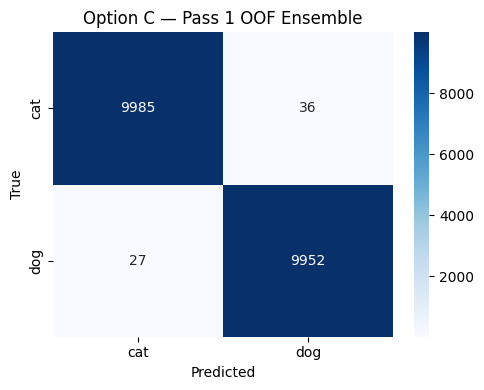


Predicted-class confidence on OOF ensemble (all 20000 samples):
  <0.5:               0  (  0.0%)
  Low 0.50–0.55:     32  (  0.2%)
  0.55–0.70:        145  (  0.7%)
  0.70–0.80:        229  (  1.1%)
  0.80–1.00:      19594  ( 98.0%)


In [7]:
model_names = [m["name"] for m in MODEL_SPECS]

# Average probabilities across all 5 models
cat_cols = [f"{m}_p_cat" for m in model_names]
dog_cols = [f"{m}_p_dog" for m in model_names]

oof_df["ens_p_cat"] = oof_df[cat_cols].mean(axis=1)
oof_df["ens_p_dog"] = oof_df[dog_cols].mean(axis=1)
oof_df["ens_pred"] = (oof_df["ens_p_dog"] > oof_df["ens_p_cat"]).astype(int)

# Agreement / disagreement stats
pred_cols = [f"{m}_pred" for m in model_names]
pred_mat = oof_df[pred_cols].values
oof_df["n_models_predict_cat"] = (pred_mat == 0).sum(axis=1)
oof_df["n_models_predict_dog"] = (pred_mat == 1).sum(axis=1)
oof_df["n_models_disagree_with_label"] = (pred_mat != oof_df["label"].values[:, None]).sum(axis=1)

# Confidence columns
ens_probs = oof_df[["ens_p_cat", "ens_p_dog"]].values
row = np.arange(len(oof_df))
ens_pred = ens_probs.argmax(axis=1)
oof_df["ens_pred_conf"] = ens_probs[row, ens_pred]
oof_df["ens_true_conf"] = np.where(oof_df["label"].values == 0, oof_df["ens_p_cat"], oof_df["ens_p_dog"])
oof_df["ens_wrong_conf"] = 1.0 - oof_df["ens_true_conf"]
oof_df["ens_prob_std"] = np.std(np.stack([oof_df[f"{m}_p_dog"].values for m in model_names], axis=1), axis=1)

y_true_oof = oof_df["label"].values
y_pred_oof = oof_df["ens_pred"].values

metrics_ens_oof = compute_metrics(y_true_oof, y_pred_oof)
print("Pass 1 OOF Ensemble Metrics:")
for k, v in metrics_ens_oof.items():
    print(f"  {k:>10s}: {v:.4f}")

cm_oof = compute_confusion_matrix(y_true_oof, y_pred_oof)
print(f"\nOOF Ensemble Confusion Matrix:\n{cm_oof}")

plot_confusion_matrix(
    cm_oof,
    class_names=CLASS_NAMES,
    title="Option C — Pass 1 OOF Ensemble",
    save_path=FIGURES_DIR / f"{PROJECT_TAG}_oof_confusion_matrix.png",
)

# Confidence buckets, same spirit as the original notebook
pred_class_prob = oof_df["ens_pred_conf"].values
n_val = len(pred_class_prob)
n_below = int((pred_class_prob < 0.50).sum())
n_b0 = int(((pred_class_prob >= 0.50) & (pred_class_prob < 0.55)).sum())
n_b1 = int(((pred_class_prob >= 0.55) & (pred_class_prob < 0.70)).sum())
n_b2 = int(((pred_class_prob >= 0.70) & (pred_class_prob < 0.80)).sum())
n_b3 = int((pred_class_prob >= 0.80).sum())

print("\nPredicted-class confidence on OOF ensemble (all %d samples):" % n_val)
print("  <0.5:           %5d  (%5.1f%%)" % (n_below, 100.0 * n_below / n_val))
print("  Low 0.50–0.55:  %5d  (%5.1f%%)" % (n_b0, 100.0 * n_b0 / n_val))
print("  0.55–0.70:      %5d  (%5.1f%%)" % (n_b1, 100.0 * n_b1 / n_val))
print("  0.70–0.80:      %5d  (%5.1f%%)" % (n_b2, 100.0 * n_b2 / n_val))
print("  0.80–1.00:      %5d  (%5.1f%%)" % (n_b3, 100.0 * n_b3 / n_val))

### Suspicion Signals
Build automatic signals to decide whether a training image should be:
- **kept**
- **downweighted**
- **removed**

Signals used here:
1. multi-model confident disagreement with the label
2. image-quality / pathology features
3. embedding-space neighbor consistency

To keep runtime realistic, embeddings are extracted only from the strongest pass-1 fold checkpoints
for **ConvNeXt-Small**.

In [8]:
# 1) Image-quality features
quality_df = compute_image_quality_features(X)
quality_path = OUTPUTS_DIR / f"{PROJECT_TAG}_image_quality_features.csv"
quality_df.to_csv(quality_path, index=False)
print(f"Saved quality features -> {quality_path}")

# 2) Embedding consistency from ConvNeXt-Small fold checkpoints
embedding_accumulator = []
embed_model_name = "convnext_small"
embed_size = next(m["input_size"] for m in MODEL_SPECS if m["name"] == embed_model_name)

for fold in range(NUM_FOLDS):
    va_idx = np.where(folds == fold)[0]
    val_loader = make_loader(X, y, va_idx, img_size=embed_size, train=False, shuffle=False)

    model = build_model(embed_model_name, device)
    ckpt_path = MODELS_DIR / f"{PROJECT_TAG}_{embed_model_name}_pass1_fold{fold}.pth"
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(normalize_ckpt_state_dict(state))

    feats, idx_fold = extract_embeddings(embed_model_name, model, val_loader, device, use_amp=USE_AMP)
    embedding_accumulator.append(pd.DataFrame({"index": idx_fold, **{f"f_{i}": feats[:, i] for i in range(feats.shape[1])}}))

    del model, val_loader, state
    gc.collect()
    if USE_CUDA:
        torch.cuda.empty_cache()

embed_df = pd.concat(embedding_accumulator, axis=0).sort_values("index").reset_index(drop=True)
feat_cols = [c for c in embed_df.columns if c.startswith("f_")]
nn_df = nearest_neighbor_consistency(embed_df[feat_cols].values.astype(np.float32), y[embed_df["index"].values], k=15)
nn_df = nn_df.sort_values("index").reset_index(drop=True)

nn_path = OUTPUTS_DIR / f"{PROJECT_TAG}_embedding_neighbor_consistency.csv"
nn_df.to_csv(nn_path, index=False)
print(f"Saved embedding consistency -> {nn_path}")

# 3) Merge all signals
analysis_df = (
    oof_df.merge(quality_df, on="index", how="left")
          .merge(nn_df, on="index", how="left")
          .sort_values("index")
          .reset_index(drop=True)
)

# Robust z-scores for quality outliers
for col in ["brightness_mean", "contrast_std", "blur_var", "entropy", "aspect_ratio"]:
    med = analysis_df[col].median()
    mad = np.median(np.abs(analysis_df[col] - med)) + 1e-9
    analysis_df[f"{col}_robust_z"] = np.abs(analysis_df[col] - med) / (1.4826 * mad)

analysis_df["quality_outlier_score"] = (
    0.20 * analysis_df["brightness_mean_robust_z"]
    + 0.20 * analysis_df["contrast_std_robust_z"]
    + 0.30 * analysis_df["blur_var_robust_z"]
    + 0.20 * analysis_df["entropy_robust_z"]
    + 0.10 * analysis_df["aspect_ratio_robust_z"]
)

# Continuous suspicion score
analysis_df["suspicion_score"] = (
    0.45 * analysis_df["ens_wrong_conf"]
    + 0.25 * (analysis_df["n_models_disagree_with_label"] / len(model_names))
    + 0.20 * analysis_df["opp_neighbor_frac"].fillna(0.0)
    + 0.10 * np.clip(analysis_df["quality_outlier_score"] / 5.0, 0, 1)
)

# Strong automatic rules for remove
# Fallback thresholds if the config cell was not re-run in this kernel.
REMOVE_SUSPICION_QUANTILE = globals().get("REMOVE_SUSPICION_QUANTILE", 0.97)
REMOVE_LOW_ENTROPY_QUANTILE = globals().get("REMOVE_LOW_ENTROPY_QUANTILE", 0.02)
REMOVE_LOW_BLUR_QUANTILE = globals().get("REMOVE_LOW_BLUR_QUANTILE", 0.02)

strict_remove_mask = (
    (analysis_df["n_models_disagree_with_label"] >= REMOVE_DISAGREE_COUNT)
    & (analysis_df["ens_wrong_conf"] >= REMOVE_WRONG_CONF)
    & (analysis_df["opp_neighbor_frac"].fillna(0.0) >= REMOVE_OPP_NEIGHBOR_FRAC)
)

# Remove the highest-suspicion tail to catch low-quality drawings/text-like outliers.
suspicion_cut = float(analysis_df["suspicion_score"].quantile(REMOVE_SUSPICION_QUANTILE))
low_entropy_cut = float(analysis_df["entropy"].quantile(REMOVE_LOW_ENTROPY_QUANTILE))
low_blur_cut = float(analysis_df["blur_var"].quantile(REMOVE_LOW_BLUR_QUANTILE))

quality_remove_mask = (
    (analysis_df["suspicion_score"] >= suspicion_cut)
    | ((analysis_df["entropy"] <= low_entropy_cut) & (analysis_df["blur_var"] <= low_blur_cut))
)

remove_mask = strict_remove_mask | quality_remove_mask

analysis_df["sample_action"] = np.where(remove_mask, "remove", "keep")
analysis_df["sample_weight"] = np.where(
    analysis_df["sample_action"] == "remove", 0.0, KEEP_VALUE
)

analysis_path = OUTPUTS_DIR / f"{PROJECT_TAG}_training_sample_actions.csv"
analysis_df.to_csv(analysis_path, index=False)
print(f"Saved final pass-1 analysis -> {analysis_path}")

print("\nSample-action summary:")
display(analysis_df["sample_action"].value_counts(dropna=False))
display(analysis_df.groupby("sample_action")[["ens_true_conf", "ens_wrong_conf", "suspicion_score"]].mean())

Image quality: 100%|██████████| 20000/20000 [00:16<00:00, 1206.20it/s]


Saved quality features -> /home/cotte/github/school/ecse415-final-project/outputs/optionC_ensemble_filtered_image_quality_features.csv
Saved embedding consistency -> /home/cotte/github/school/ecse415-final-project/outputs/optionC_ensemble_filtered_embedding_neighbor_consistency.csv
Saved final pass-1 analysis -> /home/cotte/github/school/ecse415-final-project/outputs/optionC_ensemble_filtered_training_sample_actions.csv

Sample-action summary:


sample_action
keep      19041
remove      959
Name: count, dtype: int64

,ens_true_conf,ens_wrong_conf,suspicion_score
sample_action,,,
keep,0.981155,0.018845,0.022736
remove,0.810082,0.189918,0.169391


### Suspicious Examples & Internal Review
Show the most suspicious images, and visualize:
- highest-confidence wrong OOF predictions
- highest suspicion scores
- confusion matrix based on the pass-1 ensemble OOF labels

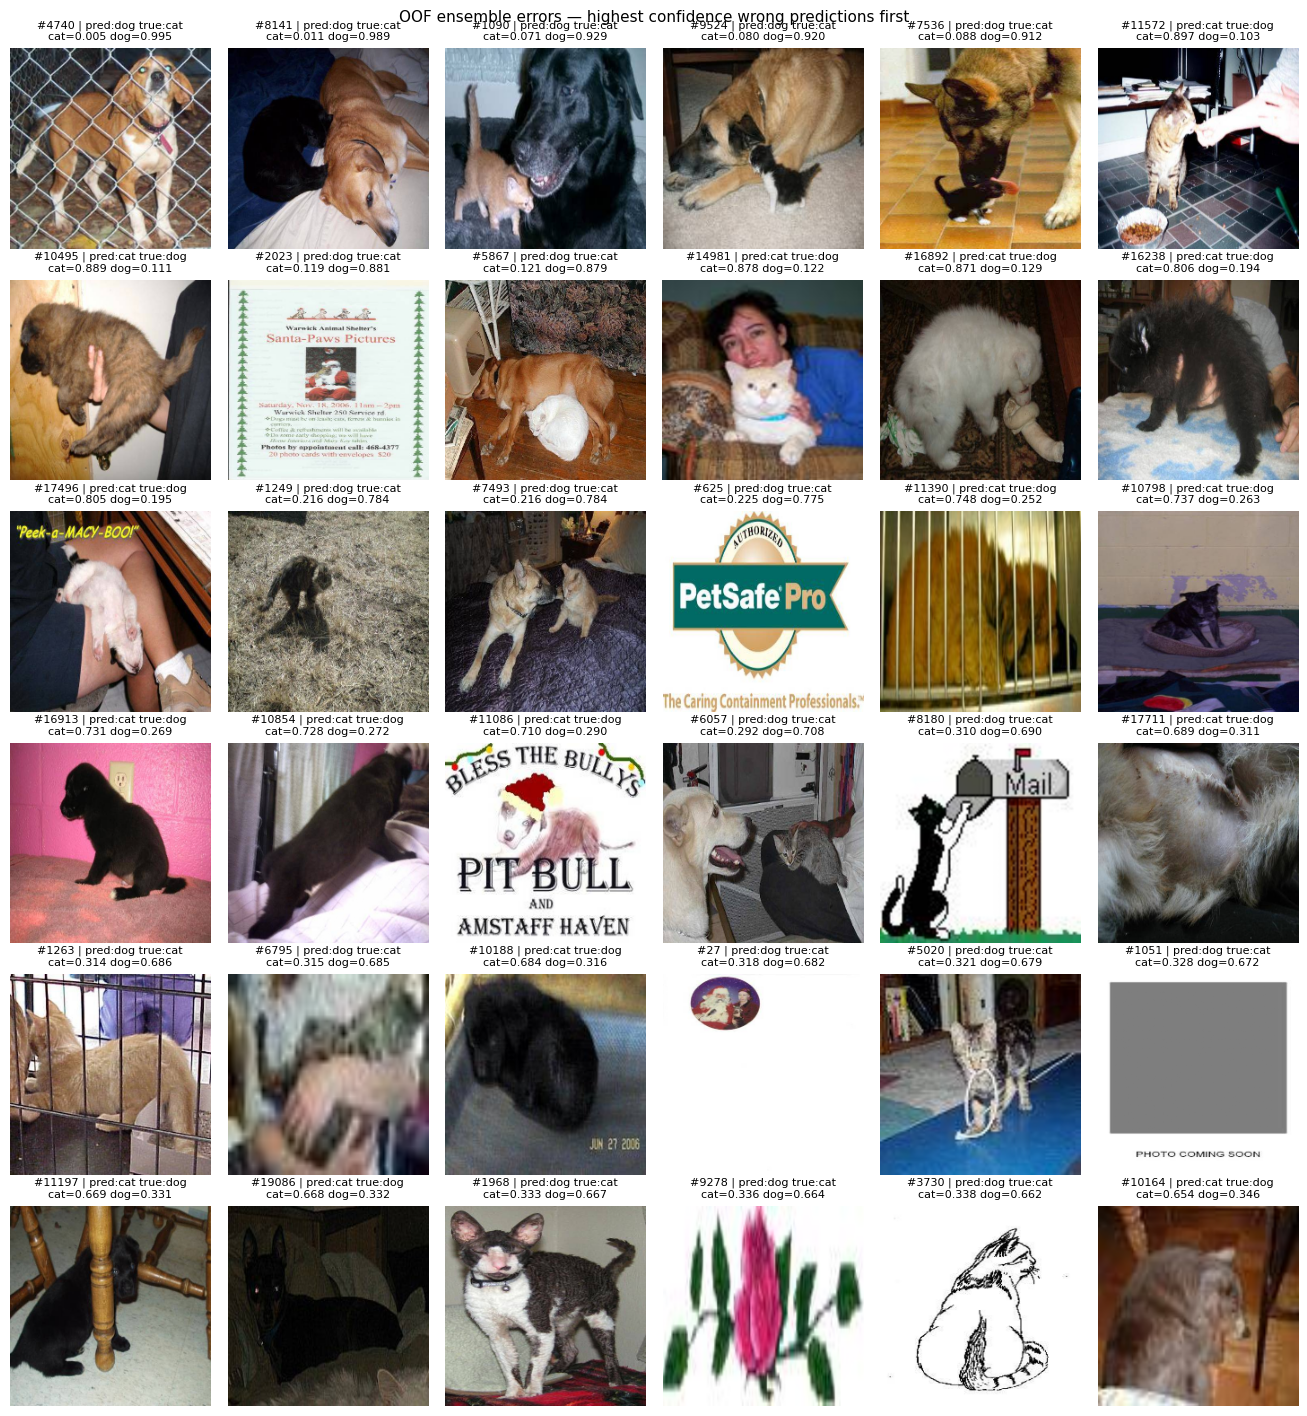

Saved optionC_ensemble_filtered_oof_errors_by_confidence.png


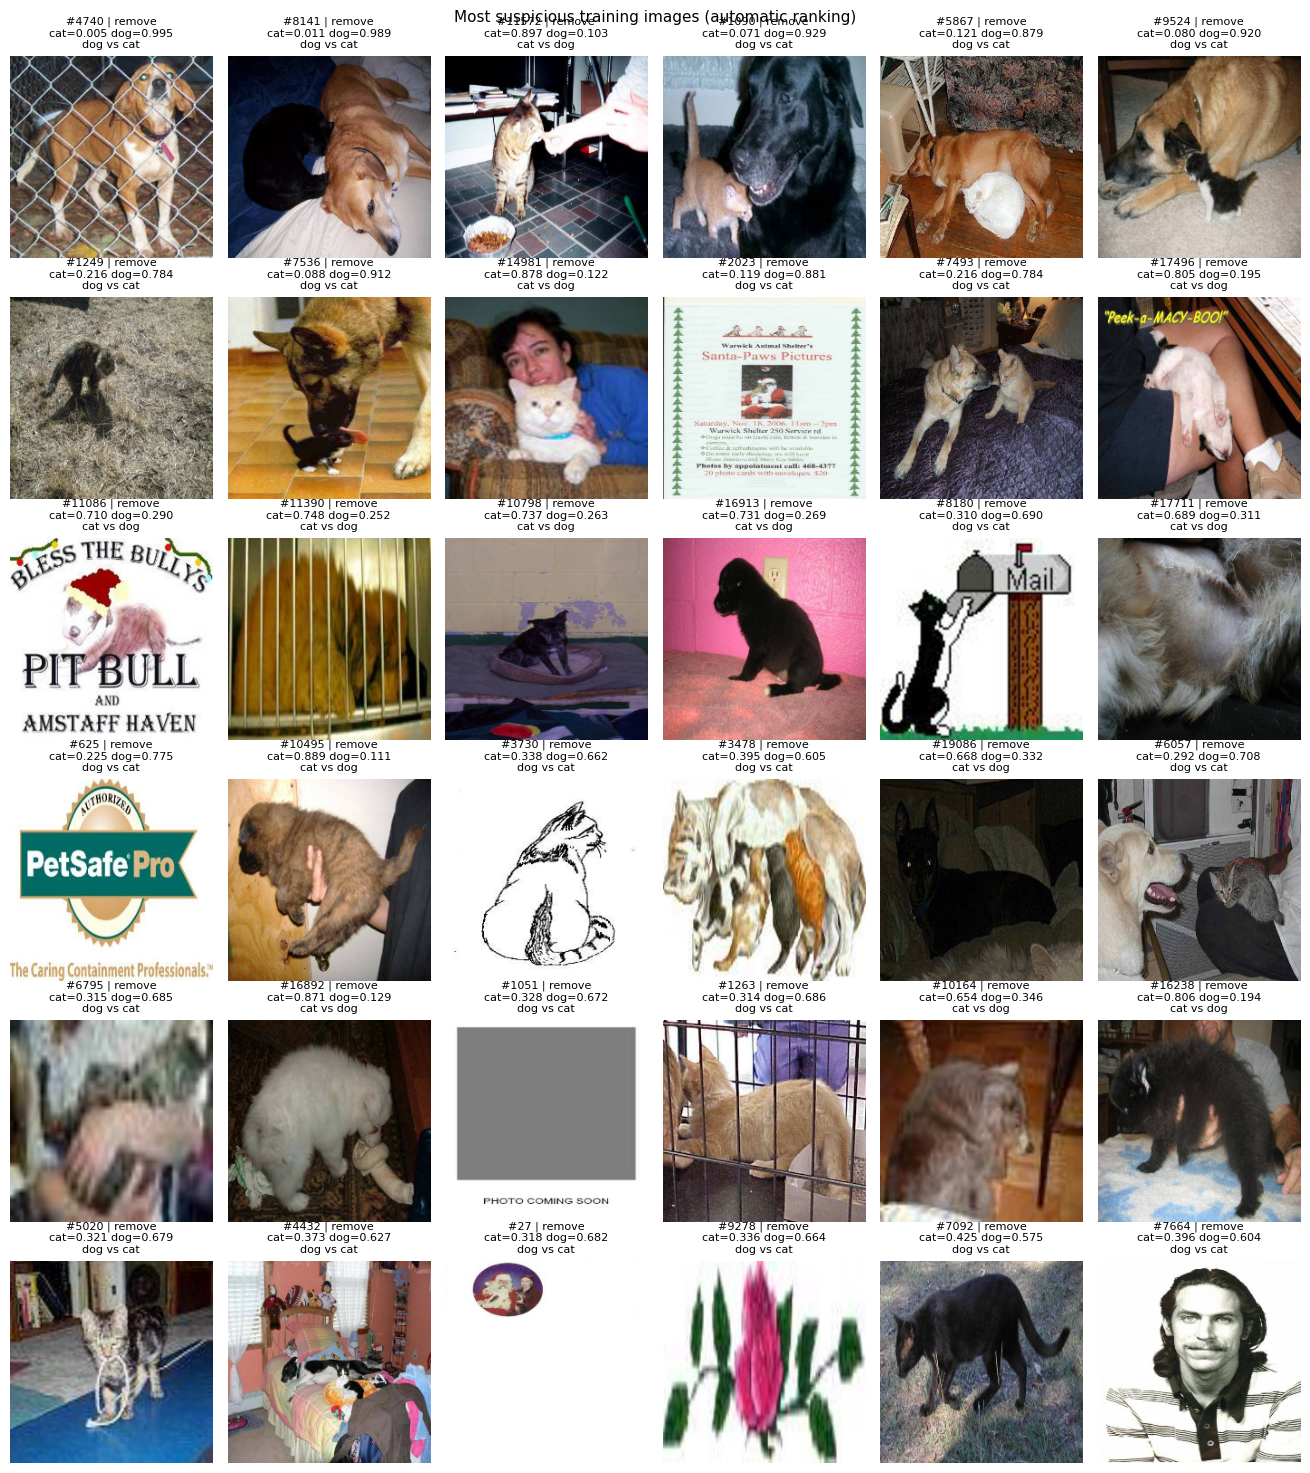

Saved optionC_ensemble_filtered_most_suspicious_images.png


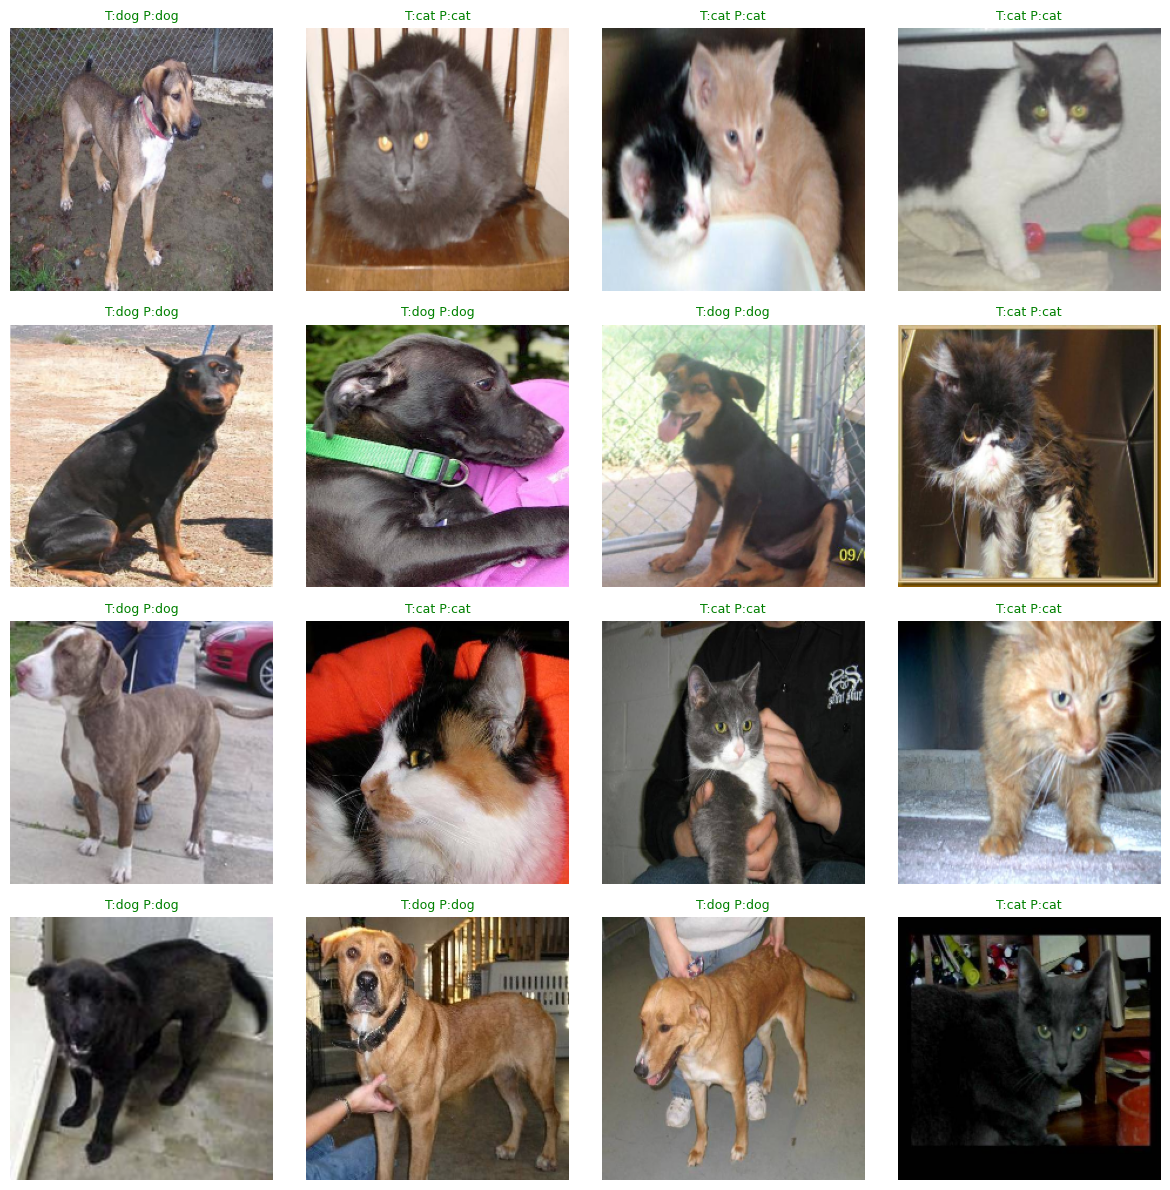

In [9]:
# Highest-confidence wrong OOF predictions
wrong_df = analysis_df[analysis_df["ens_pred"] != analysis_df["label"]].copy()
wrong_df = wrong_df.sort_values("ens_pred_conf", ascending=False)

if len(wrong_df) == 0:
    print("No wrong OOF predictions.")
else:
    n_show = min(len(wrong_df), 36)
    ncols = 6
    nrows = int(np.ceil(n_show / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 2.4))
    axes_flat = np.atleast_1d(axes).ravel()

    for j, ax in enumerate(axes_flat):
        if j < n_show:
            row = wrong_df.iloc[j]
            idx = int(row["index"])
            img = X[idx]
            ax.imshow(img)
            true_name = CLASS_NAMES[int(row["label"])]
            pred_name = CLASS_NAMES[int(row["ens_pred"])]
            p_cat = float(row["ens_p_cat"])
            p_dog = float(row["ens_p_dog"])
            ax.set_title(
                f"#{idx} | pred:{pred_name} true:{true_name}\ncat={p_cat:.3f} dog={p_dog:.3f}",
                fontsize=8,
            )
        ax.axis("off")

    fig.suptitle("OOF ensemble errors — highest confidence wrong predictions first", fontsize=11)
    fig.tight_layout()
    out_err = FIGURES_DIR / f"{PROJECT_TAG}_oof_errors_by_confidence.png"
    fig.savefig(out_err, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_err.name}")

# Highest suspicion scores
sus_df = analysis_df.sort_values("suspicion_score", ascending=False).copy()
n_show = min(len(sus_df), 36)
ncols = 6
nrows = int(np.ceil(n_show / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 2.5))
axes_flat = np.atleast_1d(axes).ravel()

for j, ax in enumerate(axes_flat):
    if j < n_show:
        row = sus_df.iloc[j]
        idx = int(row["index"])
        img = X[idx]
        ax.imshow(img)
        true_name = CLASS_NAMES[int(row["label"])]
        pred_name = CLASS_NAMES[int(row["ens_pred"])]
        action = row["sample_action"]
        p_cat = float(row["ens_p_cat"])
        p_dog = float(row["ens_p_dog"])
        ax.set_title(
            f"#{idx} | {action}\ncat={p_cat:.3f} dog={p_dog:.3f}\n{pred_name} vs {true_name}",
            fontsize=8
        )
    ax.axis("off")

fig.suptitle("Most suspicious training images (automatic ranking)", fontsize=11)
fig.tight_layout()
out_susp = FIGURES_DIR / f"{PROJECT_TAG}_most_suspicious_images.png"
fig.savefig(out_susp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_susp.name}")

# Sample predictions, same spirit as the original notebook
n_sample = min(16, len(analysis_df))
sample_rows = analysis_df.sample(n=n_sample, random_state=SEED).copy()
sample_idx = sample_rows["index"].values.astype(np.int64)

plot_sample_predictions(
    X[sample_idx],
    sample_rows["label"].values.astype(int),
    sample_rows["ens_pred"].values.astype(int),
    class_names=CLASS_NAMES,
    n=n_sample,
    save_path=FIGURES_DIR / f"{PROJECT_TAG}_sample_predictions_oof.png",
)

### Pass 2 — Final Cleaned / Weighted Training
Build the cleaned dataset:
- **remove** samples are excluded
- **downweight** samples keep a smaller sampling weight
- **keep** samples keep full weight

Then retrain all 5 models on the cleaned / weighted dataset.

In [10]:
clean_df = analysis_df[analysis_df["sample_action"] != "remove"].copy().reset_index(drop=True)
clean_indices = clean_df["index"].values.astype(np.int64)
sample_weights_full = np.where(
    analysis_df["sample_action"].values == "remove", 0.0, KEEP_VALUE
).astype(np.float32)

removed_count = int((analysis_df["sample_action"].values == "remove").sum())
removed_pct = 100.0 * removed_count / len(y)

print(f"Original samples: {len(y)}")
print(f"Kept for pass 2 : {len(clean_indices)}")
print(f"Removed for pass 2: {removed_count} ({removed_pct:.2f}%)")
print("Action counts:")
display(analysis_df["sample_action"].value_counts())

# Build a clean-train diagnostics table
clean_summary = analysis_df.groupby("sample_action").agg(
    n=("index", "count"),
    mean_true_conf=("ens_true_conf", "mean"),
    mean_suspicion=("suspicion_score", "mean"),
)
display(clean_summary)

final_histories = {}
final_model_paths = {}
final_clean_eval_rows = []

for spec in MODEL_SPECS:
    model_name = spec["name"]
    img_size = spec["input_size"]
    print("\n" + "=" * 80)
    print(f"PASS 2 CLEAN TRAIN — {model_name} @ {img_size}")
    print("=" * 80)

    # Use a small internal clean-validation split only for training curves / checkpointing.
    # This is not the pass-1 OOF evaluation; it is just a final training monitor.
    rng = np.random.default_rng(SEED)
    clean_labels = y[clean_indices]
    cat_idx = clean_indices[clean_labels == 0]
    dog_idx = clean_indices[clean_labels == 1]

    cat_perm = rng.permutation(cat_idx)
    dog_perm = rng.permutation(dog_idx)

    cat_cut = max(1, int(0.10 * len(cat_perm)))
    dog_cut = max(1, int(0.10 * len(dog_perm)))

    val_idx_final = np.concatenate([cat_perm[:cat_cut], dog_perm[:dog_cut]])
    tr_idx_final = np.setdiff1d(clean_indices, val_idx_final, assume_unique=False)

    train_loader = make_loader(
        X, y, tr_idx_final, img_size=img_size, train=True,
        sample_weights=sample_weights_full, shuffle=True
    )
    val_loader = make_loader(
        X, y, val_idx_final, img_size=img_size, train=False,
        sample_weights=None, shuffle=False
    )

    model_path = MODELS_DIR / f"{PROJECT_TAG}_{model_name}_final_clean.pth"
    skip_train = USE_CHECKPOINT_PASS2 and model_path.exists()

    model = build_model(model_name, device)

    if skip_train:
        print(f"  USE_CHECKPOINT_PASS2: {model_path.name} found — skipping training, loading weights.")
        state = torch.load(model_path, map_location=device, weights_only=True)
        model.load_state_dict(normalize_ckpt_state_dict(state))
        final_histories[model_name] = None
        best_val_acc = float("nan")
        del state
    else:
        model, history, best_val_acc = run_training_phases(
            model_name=model_name,
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            num_epochs_head=NUM_EPOCHS_HEAD_PASS2,
            num_epochs_full=NUM_EPOCHS_FULL_PASS2,
            use_amp=USE_AMP,
        )

        final_histories[model_name] = history
        torch.save(model.state_dict(), model_path)
        print(f"Saved final clean model -> {model_path}")

    probs_val, labels_val, idx_val = predict_probs(model, val_loader, device, use_amp=USE_AMP)
    preds_val = probs_val.argmax(axis=1)
    acc_val = accuracy_score(labels_val, preds_val)
    ll_val = log_loss(labels_val, probs_val, labels=[0, 1])
    final_clean_eval_rows.append({
        "model": model_name,
        "clean_internal_val_acc": acc_val,
        "clean_internal_val_logloss": ll_val,
        "best_val_acc_during_training": best_val_acc,
    })

    final_model_paths[model_name] = model_path

    del model, train_loader, val_loader
    gc.collect()
    if USE_CUDA:
        torch.cuda.empty_cache()

final_clean_eval_df = pd.DataFrame(final_clean_eval_rows)
display(final_clean_eval_df.sort_values("clean_internal_val_acc", ascending=False))

# Cat-presence model: predict whether any cat appears in the image.
CAT_PRESENCE_MODEL_NAME = "convnext_small_catPresence"
CAT_PRESENCE_INPUT_SIZE = 224


def build_binary_convnext_small(device):
    model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.DEFAULT)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, 1)
    model = model.to(device)
    return maybe_compile(model)


def get_presence_train_transform(img_size):
    return T.Compose([
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Resize((img_size, img_size)),
        T.RandomHorizontalFlip(),
        T.RandomRotation(10),
        T.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12, hue=0.03),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_presence_eval_transform(img_size):
    return T.Compose([
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Resize((img_size, img_size)),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def make_spatial_crops(arr):
    # HWC float32 [0, 1] from memmap (same as NumpyImageDataset).
    h, w = arr.shape[0], arr.shape[1]
    side = min(h, w)

    full_crop = np.array(arr, dtype=np.float32, copy=True)

    focus_side = int(0.85 * side)
    if focus_side < 1:
        focus_side = side

    cx = (w - focus_side) // 2
    cy = (h - focus_side) // 2
    center_crop = np.array(arr[cy:cy + focus_side, cx:cx + focus_side, :], dtype=np.float32, copy=True)

    top_left = np.array(arr[0:focus_side, 0:focus_side, :], dtype=np.float32, copy=True)
    top_right = np.array(arr[0:focus_side, w - focus_side:w, :], dtype=np.float32, copy=True)
    bottom_left = np.array(arr[h - focus_side:h, 0:focus_side, :], dtype=np.float32, copy=True)
    bottom_right = np.array(arr[h - focus_side:h, w - focus_side:w, :], dtype=np.float32, copy=True)

    return [full_crop, center_crop, top_left, top_right, bottom_left, bottom_right]


def sample_zoom_crop(arr, rng):
    h, w = arr.shape[0], arr.shape[1]
    side = min(h, w)

    zoom_side = int(rng.uniform(0.60, 0.95) * side)
    if zoom_side < 1:
        zoom_side = side

    max_x = max(0, w - zoom_side)
    max_y = max(0, h - zoom_side)
    left = int(rng.integers(0, max_x + 1))
    top = int(rng.integers(0, max_y + 1))

    return np.array(arr[top:top + zoom_side, left:left + zoom_side, :], dtype=np.float32, copy=True)


class CatPresenceTrainDataset(Dataset):
    def __init__(self, X, y, indices, img_size, seed):
        self.X = X
        self.y = y
        self.indices = indices.astype(np.int64)
        self.transform = get_presence_train_transform(img_size)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        arr = np.array(self.X[idx], dtype=np.float32, copy=True)

        fixed_crops = make_spatial_crops(arr)
        n_fixed = len(fixed_crops)
        pick = int(self.rng.integers(0, n_fixed + 3))

        if pick < n_fixed:
            crop_arr = fixed_crops[pick]
        else:
            crop_arr = sample_zoom_crop(arr, self.rng)

        x_tensor = self.transform(crop_arr)
        y_tensor = torch.tensor(float(self.y[idx] == 0), dtype=torch.float32)
        return x_tensor, y_tensor


class CatPresenceEvalDataset(Dataset):
    def __init__(self, X, y, indices, img_size):
        self.X = X
        self.y = y
        self.indices = indices.astype(np.int64)
        self.transform = get_presence_eval_transform(img_size)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        arr = np.array(self.X[idx], dtype=np.float32, copy=True)

        crop_arrays = make_spatial_crops(arr)
        crop_tensors = []
        for crop_arr in crop_arrays:
            crop_tensors.append(self.transform(crop_arr))

        x_stack = torch.stack(crop_tensors, dim=0)
        y_tensor = torch.tensor(float(self.y[idx] == 0), dtype=torch.float32)
        return x_stack, y_tensor


def evaluate_cat_presence(model, loader, device, use_amp):
    model.eval()
    all_labels = []
    all_probs = []

    use_autocast = use_amp and USE_CUDA

    with torch.no_grad():
        for x_batch, y_batch in loader:
            labels = y_batch.to(device, non_blocking=True)

            if x_batch.ndim == 5:
                b, n_crops, c, h, w = x_batch.shape
                x_flat = x_batch.view(b * n_crops, c, h, w).to(device, non_blocking=True)

                with torch.autocast(device_type="cuda", enabled=use_autocast):
                    logits = model(x_flat).squeeze(1)

                probs = torch.sigmoid(logits).view(b, n_crops)
                p_cat = probs.max(dim=1).values
            else:
                x_single = x_batch.to(device, non_blocking=True)
                with torch.autocast(device_type="cuda", enabled=use_autocast):
                    logits = model(x_single).squeeze(1)
                p_cat = torch.sigmoid(logits)

            all_labels.append(labels.cpu().numpy())
            all_probs.append(p_cat.cpu().numpy())

    y_true = np.concatenate(all_labels).astype(np.int64)
    p_cat = np.concatenate(all_probs).astype(np.float32)
    y_pred_cat = (p_cat >= 0.5).astype(np.int64)
    acc = accuracy_score(y_true, y_pred_cat)

    return acc, p_cat, y_true


def train_cat_presence_model(model, train_loader, val_loader, device, use_amp):
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and USE_CUDA)

    history = {
        "train_loss": [],
        "val_acc": [],
    }

    best_acc = -1.0
    best_state = None

    for p in model.features.parameters():
        p.requires_grad = False

    params_head = []
    for p in model.parameters():
        if p.requires_grad:
            params_head.append(p)

    optimizer = optim.AdamW(params_head, lr=1e-3, weight_decay=1e-4)

    use_autocast = use_amp and USE_CUDA

    n_epochs_head = NUM_EPOCHS_HEAD_PASS2
    n_epochs_full = NUM_EPOCHS_FULL_PASS2

    total_epochs = n_epochs_head + n_epochs_full

    for epoch in range(total_epochs):
        if epoch == n_epochs_head:
            for p in model.parameters():
                p.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

        model.train()
        running_loss = 0.0
        n_seen = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type="cuda", enabled=use_autocast):
                logits = model(x_batch).squeeze(1)
                loss = criterion(logits, y_batch)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = int(y_batch.shape[0])
            running_loss += float(loss.detach().cpu()) * batch_size
            n_seen += batch_size

        train_loss = running_loss / max(1, n_seen)
        val_acc, _, _ = evaluate_cat_presence(model, val_loader, device, use_amp)

        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = deepcopy(model.state_dict())

        phase_name = "head" if epoch < n_epochs_head else "full"
        print(
            f"[{CAT_PRESENCE_MODEL_NAME}] epoch {epoch + 1:02d}/{total_epochs:02d} "
            f"({phase_name}) train_loss={train_loss:.4f} val_acc={val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_acc


print("\n" + "=" * 80)
print(f"PASS 2 CLEAN TRAIN — {CAT_PRESENCE_MODEL_NAME} @ {CAT_PRESENCE_INPUT_SIZE}")
print("=" * 80)

rng_presence = np.random.default_rng(SEED)
clean_labels_presence = y[clean_indices]
cat_idx_presence = clean_indices[clean_labels_presence == 0]
dog_idx_presence = clean_indices[clean_labels_presence == 1]

cat_perm_presence = rng_presence.permutation(cat_idx_presence)
dog_perm_presence = rng_presence.permutation(dog_idx_presence)

cat_cut_presence = max(1, int(0.10 * len(cat_perm_presence)))
dog_cut_presence = max(1, int(0.10 * len(dog_perm_presence)))

val_idx_presence = np.concatenate([
    cat_perm_presence[:cat_cut_presence],
    dog_perm_presence[:dog_cut_presence],
])
tr_idx_presence = np.setdiff1d(clean_indices, val_idx_presence, assume_unique=False)

cat_presence_final_path = MODELS_DIR / f"{PROJECT_TAG}_{CAT_PRESENCE_MODEL_NAME}_final_clean.pth"
skip_presence = USE_CHECKPOINT_PASS2 and cat_presence_final_path.exists()

presence_val_ds = CatPresenceEvalDataset(
    X,
    y,
    val_idx_presence,
    img_size=CAT_PRESENCE_INPUT_SIZE,
)

presence_val_loader = DataLoader(
    presence_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=DATALOADER_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=DATALOADER_WORKERS > 0,
    prefetch_factor=PREFETCH_FACTOR if DATALOADER_WORKERS > 0 else None,
)

presence_train_loader = None
presence_train_ds = None

if not skip_presence:
    presence_train_ds = CatPresenceTrainDataset(
        X,
        y,
        tr_idx_presence,
        img_size=CAT_PRESENCE_INPUT_SIZE,
        seed=SEED,
    )

    presence_train_loader = DataLoader(
        presence_train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=DATALOADER_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=DATALOADER_WORKERS > 0,
        prefetch_factor=PREFETCH_FACTOR if DATALOADER_WORKERS > 0 else None,
    )

cat_presence_model = build_binary_convnext_small(device)

if skip_presence:
    print(f"  USE_CHECKPOINT_PASS2: {cat_presence_final_path.name} found — skipping training, loading weights.")
    presence_state = torch.load(cat_presence_final_path, map_location=device, weights_only=True)
    cat_presence_model.load_state_dict(normalize_ckpt_state_dict(presence_state))
    cat_presence_history = None
    cat_presence_best_acc = float("nan")
    del presence_state
else:
    cat_presence_model, cat_presence_history, cat_presence_best_acc = train_cat_presence_model(
        cat_presence_model,
        presence_train_loader,
        presence_val_loader,
        device,
        use_amp=USE_AMP,
    )

    torch.save(cat_presence_model.state_dict(), cat_presence_final_path)
    print(f"Saved final clean model -> {cat_presence_final_path}")

cat_presence_val_acc, cat_presence_val_p_cat, cat_presence_val_y = evaluate_cat_presence(
    cat_presence_model,
    presence_val_loader,
    device,
    use_amp=USE_AMP,
)

final_model_paths[CAT_PRESENCE_MODEL_NAME] = cat_presence_final_path

final_clean_eval_rows.append({
    "model": CAT_PRESENCE_MODEL_NAME,
    "clean_internal_val_acc": float(cat_presence_val_acc),
    "clean_internal_val_logloss": float("nan"),
    "best_val_acc_during_training": float(cat_presence_best_acc),
})

print(f"Cat-presence validation acc: {cat_presence_val_acc:.5f}")

final_clean_eval_df = pd.DataFrame(final_clean_eval_rows)
display(final_clean_eval_df.sort_values("clean_internal_val_acc", ascending=False))

if "cat_presence_model" in locals():
    del cat_presence_model

del presence_val_loader, presence_val_ds

if presence_train_loader is not None:
    del presence_train_loader

if presence_train_ds is not None:
    del presence_train_ds
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()


# Dog-presence model: predict whether any dog appears in the image.
DOG_PRESENCE_MODEL_NAME = "convnext_small_dogPresence"
DOG_PRESENCE_INPUT_SIZE = 224


class DogPresenceTrainDataset(Dataset):
    def __init__(self, X, y, indices, img_size, seed):
        self.X = X
        self.y = y
        self.indices = indices.astype(np.int64)
        self.transform = get_presence_train_transform(img_size)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        arr = np.array(self.X[idx], dtype=np.float32, copy=True)

        fixed_crops = make_spatial_crops(arr)
        n_fixed = len(fixed_crops)
        pick = int(self.rng.integers(0, n_fixed + 3))

        if pick < n_fixed:
            crop_arr = fixed_crops[pick]
        else:
            crop_arr = sample_zoom_crop(arr, self.rng)

        x_tensor = self.transform(crop_arr)
        y_tensor = torch.tensor(float(self.y[idx] == 1), dtype=torch.float32)
        return x_tensor, y_tensor


class DogPresenceEvalDataset(Dataset):
    def __init__(self, X, y, indices, img_size):
        self.X = X
        self.y = y
        self.indices = indices.astype(np.int64)
        self.transform = get_presence_eval_transform(img_size)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        arr = np.array(self.X[idx], dtype=np.float32, copy=True)

        crop_arrays = make_spatial_crops(arr)
        crop_tensors = []
        for crop_arr in crop_arrays:
            crop_tensors.append(self.transform(crop_arr))

        x_stack = torch.stack(crop_tensors, dim=0)
        y_tensor = torch.tensor(float(self.y[idx] == 1), dtype=torch.float32)
        return x_stack, y_tensor


def evaluate_dog_presence(model, loader, device, use_amp):
    model.eval()
    all_labels = []
    all_probs = []

    use_autocast = use_amp and USE_CUDA

    with torch.no_grad():
        for x_batch, y_batch in loader:
            labels = y_batch.to(device, non_blocking=True)

            if x_batch.ndim == 5:
                b, n_crops, c, h, w = x_batch.shape
                x_flat = x_batch.view(b * n_crops, c, h, w).to(device, non_blocking=True)

                with torch.autocast(device_type="cuda", enabled=use_autocast):
                    logits = model(x_flat).squeeze(1)

                probs = torch.sigmoid(logits).view(b, n_crops)
                p_dog = probs.max(dim=1).values
            else:
                x_single = x_batch.to(device, non_blocking=True)
                with torch.autocast(device_type="cuda", enabled=use_autocast):
                    logits = model(x_single).squeeze(1)
                p_dog = torch.sigmoid(logits)

            all_labels.append(labels.cpu().numpy())
            all_probs.append(p_dog.cpu().numpy())

    y_true = np.concatenate(all_labels).astype(np.int64)
    p_dog = np.concatenate(all_probs).astype(np.float32)
    y_pred_dog = (p_dog >= 0.5).astype(np.int64)
    acc = accuracy_score(y_true, y_pred_dog)

    return acc, p_dog, y_true


def train_dog_presence_model(model, train_loader, val_loader, device, use_amp):
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and USE_CUDA)

    history = {
        "train_loss": [],
        "val_acc": [],
    }

    best_acc = -1.0
    best_state = None

    for p in model.features.parameters():
        p.requires_grad = False

    params_head = []
    for p in model.parameters():
        if p.requires_grad:
            params_head.append(p)

    optimizer = optim.AdamW(params_head, lr=1e-3, weight_decay=1e-4)

    use_autocast = use_amp and USE_CUDA

    n_epochs_head = NUM_EPOCHS_HEAD_PASS2
    n_epochs_full = NUM_EPOCHS_FULL_PASS2

    total_epochs = n_epochs_head + n_epochs_full

    for epoch in range(total_epochs):
        if epoch == n_epochs_head:
            for p in model.parameters():
                p.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

        model.train()
        running_loss = 0.0
        n_seen = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type="cuda", enabled=use_autocast):
                logits = model(x_batch).squeeze(1)
                loss = criterion(logits, y_batch)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = int(y_batch.shape[0])
            running_loss += float(loss.detach().cpu()) * batch_size
            n_seen += batch_size

        train_loss = running_loss / max(1, n_seen)
        val_acc, _, _ = evaluate_dog_presence(model, val_loader, device, use_amp)

        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = deepcopy(model.state_dict())

        phase_name = "head" if epoch < n_epochs_head else "full"
        print(
            f"[{DOG_PRESENCE_MODEL_NAME}] epoch {epoch + 1:02d}/{total_epochs:02d} "
            f"({phase_name}) train_loss={train_loss:.4f} val_acc={val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_acc


print("\n" + "=" * 80)
print(f"PASS 2 CLEAN TRAIN — {DOG_PRESENCE_MODEL_NAME} @ {DOG_PRESENCE_INPUT_SIZE}")
print("=" * 80)

# Same clean train/val indices as cat-presence.
val_idx_dog = val_idx_presence
tr_idx_dog = tr_idx_presence

dog_presence_final_path = MODELS_DIR / f"{PROJECT_TAG}_{DOG_PRESENCE_MODEL_NAME}_final_clean.pth"
skip_dog_presence = USE_CHECKPOINT_PASS2 and dog_presence_final_path.exists()

dog_val_ds = DogPresenceEvalDataset(
    X,
    y,
    val_idx_dog,
    img_size=DOG_PRESENCE_INPUT_SIZE,
)

dog_val_loader = DataLoader(
    dog_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=DATALOADER_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=DATALOADER_WORKERS > 0,
    prefetch_factor=PREFETCH_FACTOR if DATALOADER_WORKERS > 0 else None,
)

dog_train_loader = None
dog_train_ds = None

if not skip_dog_presence:
    dog_train_ds = DogPresenceTrainDataset(
        X,
        y,
        tr_idx_dog,
        img_size=DOG_PRESENCE_INPUT_SIZE,
        seed=SEED,
    )

    dog_train_loader = DataLoader(
        dog_train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=DATALOADER_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=DATALOADER_WORKERS > 0,
        prefetch_factor=PREFETCH_FACTOR if DATALOADER_WORKERS > 0 else None,
    )

dog_presence_model = build_binary_convnext_small(device)

if skip_dog_presence:
    print(f"  USE_CHECKPOINT_PASS2: {dog_presence_final_path.name} found — skipping training, loading weights.")
    dog_presence_state = torch.load(dog_presence_final_path, map_location=device, weights_only=True)
    dog_presence_model.load_state_dict(normalize_ckpt_state_dict(dog_presence_state))
    dog_presence_history = None
    dog_presence_best_acc = float("nan")
    del dog_presence_state
else:
    dog_presence_model, dog_presence_history, dog_presence_best_acc = train_dog_presence_model(
        dog_presence_model,
        dog_train_loader,
        dog_val_loader,
        device,
        use_amp=USE_AMP,
    )

    torch.save(dog_presence_model.state_dict(), dog_presence_final_path)
    print(f"Saved final clean model -> {dog_presence_final_path}")

dog_presence_val_acc, dog_presence_val_p_dog, dog_presence_val_y = evaluate_dog_presence(
    dog_presence_model,
    dog_val_loader,
    device,
    use_amp=USE_AMP,
)

final_model_paths[DOG_PRESENCE_MODEL_NAME] = dog_presence_final_path

final_clean_eval_rows.append({
    "model": DOG_PRESENCE_MODEL_NAME,
    "clean_internal_val_acc": float(dog_presence_val_acc),
    "clean_internal_val_logloss": float("nan"),
    "best_val_acc_during_training": float(dog_presence_best_acc),
})

print(f"Dog-presence validation acc: {dog_presence_val_acc:.5f}")

final_clean_eval_df = pd.DataFrame(final_clean_eval_rows)
display(final_clean_eval_df.sort_values("clean_internal_val_acc", ascending=False))

if "dog_presence_model" in locals():
    del dog_presence_model

del dog_val_loader, dog_val_ds

if dog_train_loader is not None:
    del dog_train_loader

if dog_train_ds is not None:
    del dog_train_ds
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()


Original samples: 20000
Kept for pass 2 : 19041
Removed for pass 2: 959 (4.79%)
Action counts:


sample_action
keep      19041
remove      959
Name: count, dtype: int64

,n,mean_true_conf,mean_suspicion
sample_action,,,
keep,19041,0.981155,0.022736
remove,959,0.810082,0.169391



PASS 2 CLEAN TRAIN — resnet50 @ 224
  USE_CHECKPOINT_PASS2: optionC_ensemble_filtered_resnet50_final_clean.pth found — skipping training, loading weights.

PASS 2 CLEAN TRAIN — convnext_tiny @ 224
  USE_CHECKPOINT_PASS2: optionC_ensemble_filtered_convnext_tiny_final_clean.pth found — skipping training, loading weights.

PASS 2 CLEAN TRAIN — convnext_small @ 224
  USE_CHECKPOINT_PASS2: optionC_ensemble_filtered_convnext_small_final_clean.pth found — skipping training, loading weights.

PASS 2 CLEAN TRAIN — efficientnet_b3 @ 300
  USE_CHECKPOINT_PASS2: optionC_ensemble_filtered_efficientnet_b3_final_clean.pth found — skipping training, loading weights.

PASS 2 CLEAN TRAIN — efficientnet_b4 @ 380
  USE_CHECKPOINT_PASS2: optionC_ensemble_filtered_efficientnet_b4_final_clean.pth found — skipping training, loading weights.


,model,clean_internal_val_acc,clean_internal_val_logloss,best_val_acc_during_training
0,resnet50,1.0,0.019746,NaN
1,convnext_tiny,1.0,0.014825,NaN
2,convnext_small,1.0,0.010129,NaN
3,efficientnet_b3,1.0,0.015007,NaN
4,efficientnet_b4,1.0,0.013070,NaN



PASS 2 CLEAN TRAIN — convnext_small_catPresence @ 224
  USE_CHECKPOINT_PASS2: optionC_ensemble_filtered_convnext_small_catPresence_final_clean.pth found — skipping training, loading weights.
Cat-presence validation acc: 1.00000


,model,clean_internal_val_acc,clean_internal_val_logloss,best_val_acc_during_training
0,resnet50,1.0,0.019746,NaN
1,convnext_tiny,1.0,0.014825,NaN
2,convnext_small,1.0,0.010129,NaN
3,efficientnet_b3,1.0,0.015007,NaN
4,efficientnet_b4,1.0,0.013070,NaN
5,convnext_small_catPresence,1.0,NaN,NaN



PASS 2 CLEAN TRAIN — convnext_small_dogPresence @ 224
[convnext_small_dogPresence] epoch 01/22 (head) train_loss=0.0462 val_acc=0.9995
[convnext_small_dogPresence] epoch 02/22 (head) train_loss=0.0071 val_acc=0.9995
[convnext_small_dogPresence] epoch 03/22 (head) train_loss=0.0051 val_acc=0.9995
[convnext_small_dogPresence] epoch 04/22 (head) train_loss=0.0052 val_acc=0.9995
[convnext_small_dogPresence] epoch 05/22 (head) train_loss=0.0045 val_acc=0.9995
[convnext_small_dogPresence] epoch 06/22 (head) train_loss=0.0038 val_acc=0.9995
[convnext_small_dogPresence] epoch 07/22 (head) train_loss=0.0031 val_acc=0.9995
[convnext_small_dogPresence] epoch 08/22 (head) train_loss=0.0034 val_acc=0.9995
[convnext_small_dogPresence] epoch 09/22 (full) train_loss=0.0037 val_acc=1.0000
[convnext_small_dogPresence] epoch 10/22 (full) train_loss=0.0019 val_acc=0.9989
[convnext_small_dogPresence] epoch 11/22 (full) train_loss=0.0035 val_acc=0.9979
[convnext_small_dogPresence] epoch 12/22 (full) train_

,model,clean_internal_val_acc,clean_internal_val_logloss,best_val_acc_during_training
0,resnet50,1.0,0.019746,NaN
1,convnext_tiny,1.0,0.014825,NaN
2,convnext_small,1.0,0.010129,NaN
3,efficientnet_b3,1.0,0.015007,NaN
4,efficientnet_b4,1.0,0.013070,NaN
5,convnext_small_catPresence,1.0,NaN,NaN
6,convnext_small_dogPresence,1.0,NaN,1.0


### Training Curves (Final Cleaned Models)
Plot the final cleaned-data training history for each model family.

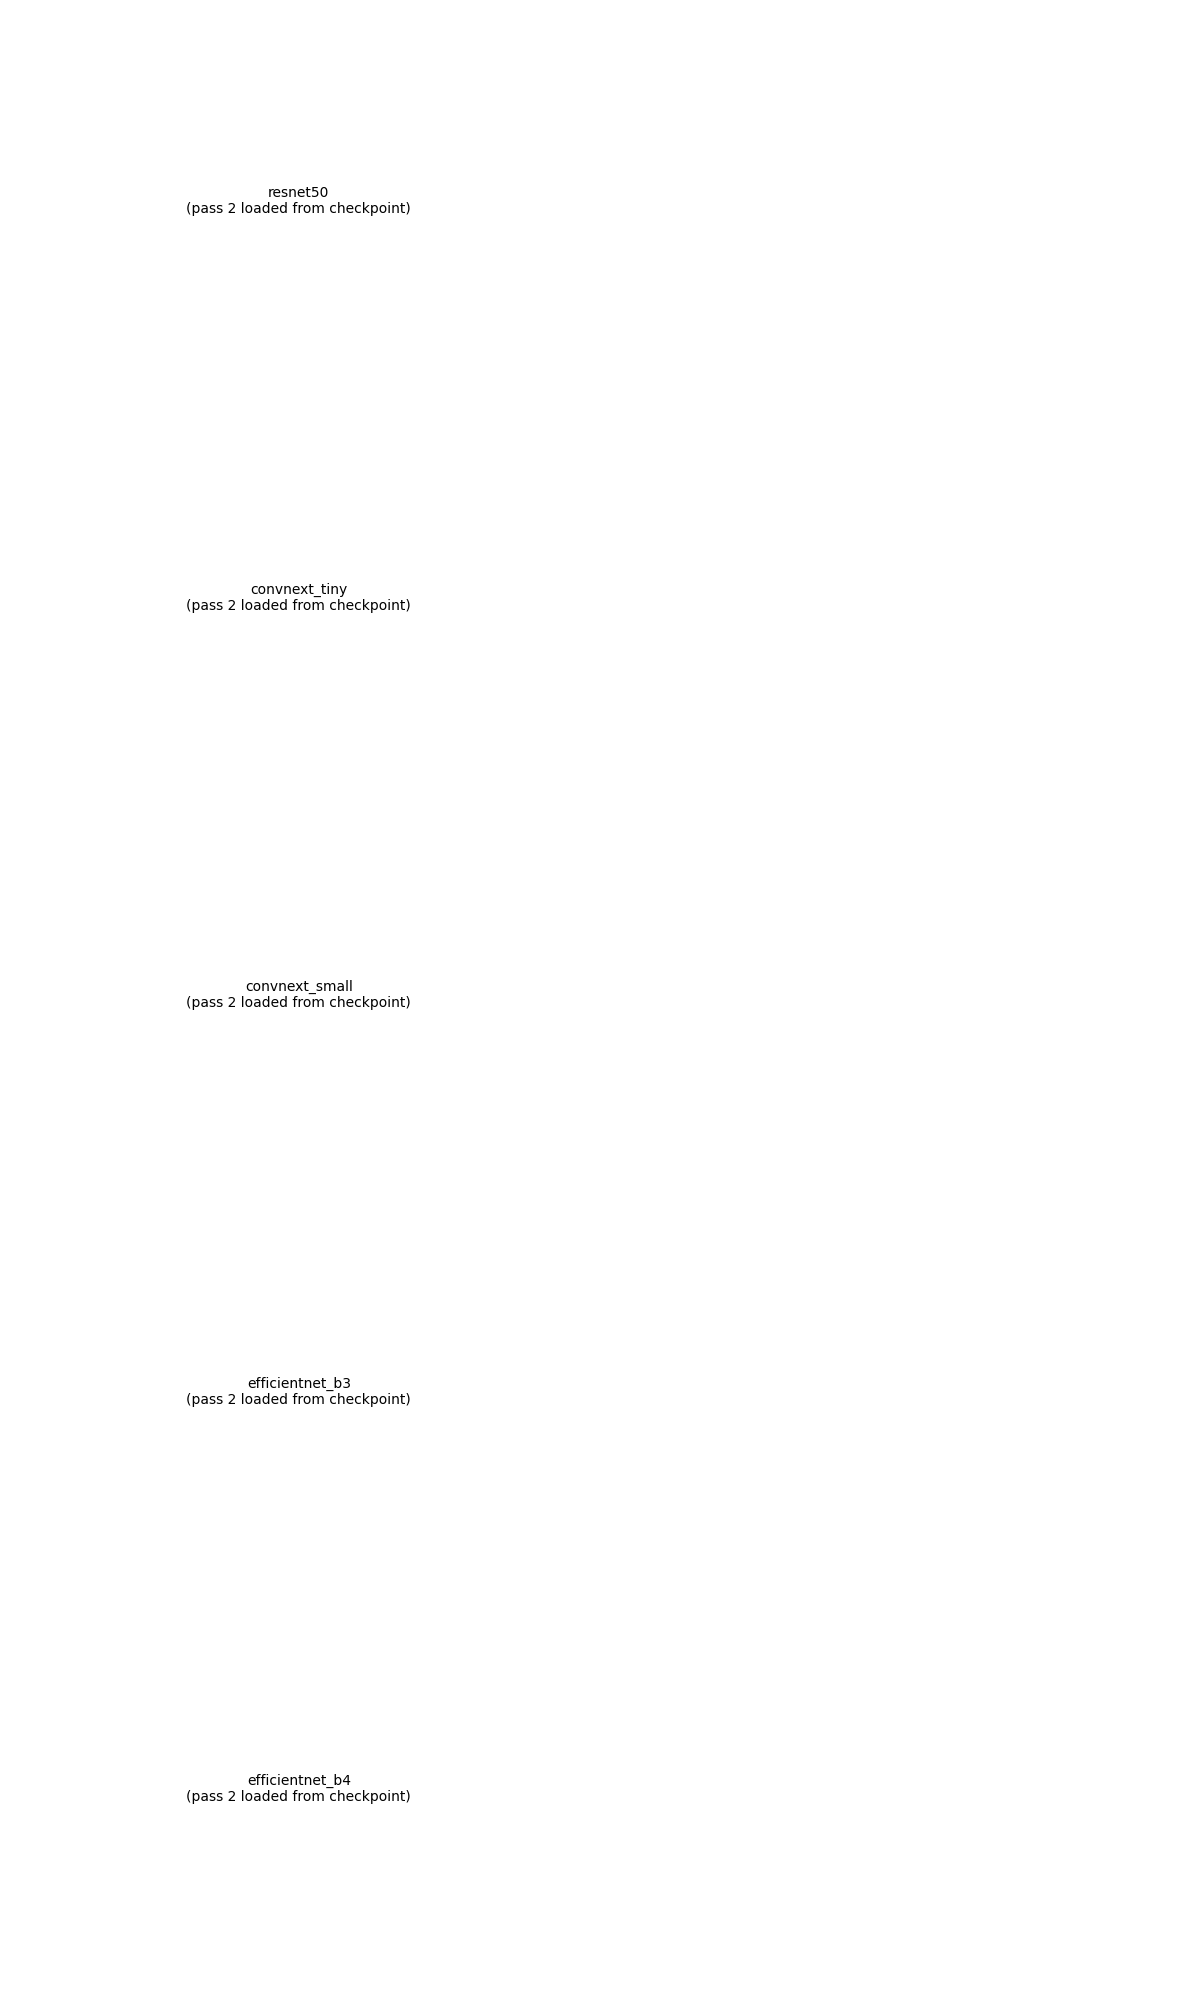

Saved -> /home/cotte/github/school/ecse415-final-project/outputs/figures/optionC_ensemble_filtered_final_clean_training_curves.png


In [11]:
fig, axes = plt.subplots(len(MODEL_SPECS), 2, figsize=(12, 4 * len(MODEL_SPECS)))
if len(MODEL_SPECS) == 1:
    axes = np.array([axes])

for r, spec in enumerate(MODEL_SPECS):
    name = spec["name"]
    hist = final_histories[name]

    ax0 = axes[r, 0]
    ax1 = axes[r, 1]

    if hist is None:
        ax0.axis("off")
        ax1.axis("off")
        ax0.text(
            0.5,
            0.5,
            f"{name}\n(pass 2 loaded from checkpoint)",
            transform=ax0.transAxes,
            ha="center",
            va="center",
        )
        continue

    ax = ax0
    ax.plot(hist["train_loss"], label="train")
    ax.plot(hist["val_loss"], label="val")
    ax.set_title(f"{name} — Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = ax1
    ax.plot(hist["train_acc"], label="train")
    ax.plot(hist["val_acc"], label="val")
    ax.set_title(f"{name} — Accuracy")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
hist_path = FIGURES_DIR / f"{PROJECT_TAG}_final_clean_training_curves.png"
fig.savefig(hist_path, dpi=150)
plt.show()
print(f"Saved -> {hist_path}")

### Save Pass 1 / Pass 2 Metrics
Persist all key tables so the next notebook can load them if needed.

In [12]:
metrics_bundle = {
    "pass1_oof_ensemble_metrics": metrics_ens_oof,
    "pass1_action_counts": analysis_df["sample_action"].value_counts().to_dict(),
    "pass2_clean_internal_summary": final_clean_eval_df.to_dict(orient="records"),
}

metrics_path = MODELS_DIR / f"{PROJECT_TAG}_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_bundle, f, indent=2)

final_eval_path = OUTPUTS_DIR / f"{PROJECT_TAG}_pass2_clean_internal_eval.csv"
final_clean_eval_df.to_csv(final_eval_path, index=False)

print(f"Saved metrics -> {metrics_path}")
print(f"Saved clean eval table -> {final_eval_path}")
metrics_bundle

Saved metrics -> /home/cotte/github/school/ecse415-final-project/outputs/models/optionC_ensemble_filtered_metrics.json
Saved clean eval table -> /home/cotte/github/school/ecse415-final-project/outputs/optionC_ensemble_filtered_pass2_clean_internal_eval.csv


{'pass1_oof_ensemble_metrics': {'accuracy': 0.99685,
  'precision': 0.9963956748097718,
  'recall': 0.9972943180679427,
  'f1': 0.9968447939099514},
 'pass1_action_counts': {'keep': 19041, 'remove': 959},
 'pass2_clean_internal_summary': [{'model': 'resnet50',
   'clean_internal_val_acc': 1.0,
   'clean_internal_val_logloss': 0.019746339097286656,
   'best_val_acc_during_training': nan},
  {'model': 'convnext_tiny',
   'clean_internal_val_acc': 1.0,
   'clean_internal_val_logloss': 0.014824880243901752,
   'best_val_acc_during_training': nan},
  {'model': 'convnext_small',
   'clean_internal_val_acc': 1.0,
   'clean_internal_val_logloss': 0.010128748648270843,
   'best_val_acc_during_training': nan},
  {'model': 'efficientnet_b3',
   'clean_internal_val_acc': 1.0,
   'clean_internal_val_logloss': 0.015006588366665392,
   'best_val_acc_during_training': nan},
  {'model': 'efficientnet_b4',
   'clean_internal_val_acc': 1.0,
   'clean_internal_val_logloss': 0.013070342200898973,
   'best_

### Kaggle Test Inference & Final Oracle Submission
Load the Kaggle test set, run all 7 final models, merge probabilities with the oracle function, and export only one final submission file.


In [13]:
# Load unlabeled Kaggle test images once
X_test, test_ids = load_test_images_memmap(img_size=IMG_SIZE_CNN, grayscale=False)
print(f"Test images: {X_test.shape}, IDs: {len(test_ids)}")

class NumpyTestDataset(Dataset):
    def __init__(self, X, img_size):
        self.X = X
        self.transform = make_transforms(img_size, train=False)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.transform(self.X[idx]), idx

test_probs_tables = []
ensemble_prob_sum = None
model_test_preds = {}
model_test_p_dog = {}

for spec in MODEL_SPECS:
    model_name = spec["name"]
    img_size = spec["input_size"]
    print("\n" + "=" * 80)
    print(f"TEST INFERENCE — {model_name} @ {img_size}")
    print("=" * 80)

    test_ds = NumpyTestDataset(X_test, img_size=img_size)
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=DATALOADER_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=DATALOADER_WORKERS > 0,
        prefetch_factor=PREFETCH_FACTOR if DATALOADER_WORKERS > 0 else None,
    )

    model = build_model(model_name, device)
    state = torch.load(final_model_paths[model_name], map_location=device)
    model.load_state_dict(normalize_ckpt_state_dict(state))

    probs, _, idx_test = predict_probs(model, test_loader, device, use_amp=USE_AMP)
    preds_single = probs.argmax(axis=1).astype(int)
    model_test_preds[model_name] = preds_single
    model_test_p_dog[model_name] = probs[:, 1].astype(float)

    df_probs = pd.DataFrame({
        "index": idx_test.astype(int),
        f"{model_name}_p_cat": probs[:, 0],
        f"{model_name}_p_dog": probs[:, 1],
    }).sort_values("index").reset_index(drop=True)
    test_probs_tables.append(df_probs)

    if ensemble_prob_sum is None:
        ensemble_prob_sum = probs
    else:
        ensemble_prob_sum += probs

    del model, test_loader, test_ds, state
    gc.collect()
    if USE_CUDA:
        torch.cuda.empty_cache()

ensemble_probs = ensemble_prob_sum / len(MODEL_SPECS)
test_pred = ensemble_probs.argmax(axis=1).astype(int)

test_probs_df = test_probs_tables[0]
for tdf in test_probs_tables[1:]:
    test_probs_df = test_probs_df.merge(tdf, on="index", how="left")
test_probs_df["ens_p_cat"] = ensemble_probs[:, 0]
test_probs_df["ens_p_dog"] = ensemble_probs[:, 1]
test_probs_df["ens_pred"] = test_pred
test_probs_df["id"] = test_ids

test_probs_path = OUTPUTS_DIR / f"{PROJECT_TAG}_test_probs_per_model.csv"
test_probs_df.to_csv(test_probs_path, index=False)
print(f"Saved per-model test probabilities -> {test_probs_path}")

submissions_dir = OUTPUTS_DIR / "submissions"
submissions_dir.mkdir(parents=True, exist_ok=True)

print("Base-model inference complete. Final single submission will be written after all 7 model probabilities are available.")


class CatPresenceTestDataset(Dataset):
    def __init__(self, X, img_size):
        self.X = X
        self.img_size = img_size
        self.transform = get_presence_eval_transform(img_size)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        arr = np.array(self.X[idx], dtype=np.float32, copy=True)
        crop_arrays = make_spatial_crops(arr)

        crop_tensors = []
        for crop_arr in crop_arrays:
            crop_tensors.append(self.transform(crop_arr))

        x_stack = torch.stack(crop_tensors, dim=0)
        return x_stack, idx


print("\n" + "=" * 80)
print(f"TEST INFERENCE — {CAT_PRESENCE_MODEL_NAME} @ {CAT_PRESENCE_INPUT_SIZE}")
print("=" * 80)

presence_test_ds = CatPresenceTestDataset(X_test, img_size=CAT_PRESENCE_INPUT_SIZE)
presence_test_loader = DataLoader(
    presence_test_ds,
    batch_size=max(1, BATCH_SIZE // 2),
    shuffle=False,
    num_workers=DATALOADER_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=DATALOADER_WORKERS > 0,
    prefetch_factor=PREFETCH_FACTOR if DATALOADER_WORKERS > 0 else None,
)

presence_model = build_binary_convnext_small(device)
presence_state = torch.load(final_model_paths[CAT_PRESENCE_MODEL_NAME], map_location=device)
presence_model.load_state_dict(normalize_ckpt_state_dict(presence_state))
presence_model.eval()

presence_idx_all = []
presence_p_cat_all = []

use_autocast = USE_AMP and USE_CUDA

with torch.no_grad():
    for x_batch, idx_batch in presence_test_loader:
        b, n_crops, c, h, w = x_batch.shape
        x_flat = x_batch.view(b * n_crops, c, h, w).to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_autocast):
            logits = presence_model(x_flat).squeeze(1)

        p_cat = torch.sigmoid(logits).view(b, n_crops).max(dim=1).values

        presence_idx_all.append(idx_batch.numpy())
        presence_p_cat_all.append(p_cat.cpu().numpy())

presence_idx = np.concatenate(presence_idx_all).astype(np.int64)
presence_p_cat = np.concatenate(presence_p_cat_all).astype(np.float32)
presence_p_not_cat = 1.0 - presence_p_cat
presence_pred_not_cat = (presence_p_not_cat >= 0.5).astype(int)

cat_presence_df = pd.DataFrame({
    "index": presence_idx,
    "cat_presence_p_cat": presence_p_cat,
    "cat_presence_p_not_cat": presence_p_not_cat,
    "cat_presence_pred_not_cat": presence_pred_not_cat,
}).sort_values("index").reset_index(drop=True)
cat_presence_df["id"] = test_ids

test_probs_df = test_probs_df.merge(
    cat_presence_df[["index", "cat_presence_p_cat", "cat_presence_p_not_cat", "cat_presence_pred_not_cat"]],
    on="index",
    how="left",
)

test_probs_df.to_csv(test_probs_path, index=False)
print(f"Updated per-model test probabilities with cat-presence -> {test_probs_path}")

print(f"Cat-presence inference ready. Rows: {len(test_ids)}  Not-cat(1): {(presence_pred_not_cat == 1).sum()}  Cat(0): {(presence_pred_not_cat == 0).sum()}")

if "presence_model" in locals():
    del presence_model

del presence_test_loader, presence_test_ds, presence_state
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()


class DogPresenceTestDataset(Dataset):
    def __init__(self, X, img_size):
        self.X = X
        self.img_size = img_size
        self.transform = get_presence_eval_transform(img_size)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        arr = np.array(self.X[idx], dtype=np.float32, copy=True)
        crop_arrays = make_spatial_crops(arr)

        crop_tensors = []
        for crop_arr in crop_arrays:
            crop_tensors.append(self.transform(crop_arr))

        x_stack = torch.stack(crop_tensors, dim=0)
        return x_stack, idx


print("\n" + "=" * 80)
print(f"TEST INFERENCE — {DOG_PRESENCE_MODEL_NAME} @ {DOG_PRESENCE_INPUT_SIZE}")
print("=" * 80)

dog_test_ds = DogPresenceTestDataset(X_test, img_size=DOG_PRESENCE_INPUT_SIZE)
dog_test_loader = DataLoader(
    dog_test_ds,
    batch_size=max(1, BATCH_SIZE // 2),
    shuffle=False,
    num_workers=DATALOADER_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=DATALOADER_WORKERS > 0,
    prefetch_factor=PREFETCH_FACTOR if DATALOADER_WORKERS > 0 else None,
)

dog_presence_infer = build_binary_convnext_small(device)
dog_presence_state = torch.load(final_model_paths[DOG_PRESENCE_MODEL_NAME], map_location=device)
dog_presence_infer.load_state_dict(normalize_ckpt_state_dict(dog_presence_state))
dog_presence_infer.eval()

dog_idx_all = []
dog_p_dog_all = []

with torch.no_grad():
    for x_batch, idx_batch in dog_test_loader:
        b, n_crops, c, h, w = x_batch.shape
        x_flat = x_batch.view(b * n_crops, c, h, w).to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_autocast):
            logits = dog_presence_infer(x_flat).squeeze(1)

        p_dog_batch = torch.sigmoid(logits).view(b, n_crops).max(dim=1).values

        dog_idx_all.append(idx_batch.numpy())
        dog_p_dog_all.append(p_dog_batch.cpu().numpy())

dog_idx = np.concatenate(dog_idx_all).astype(np.int64)
dog_p_dog = np.concatenate(dog_p_dog_all).astype(np.float32)
dog_p_not_dog = 1.0 - dog_p_dog
dog_pred_dog = (dog_p_dog >= 0.5).astype(int)

dog_presence_df = pd.DataFrame({
    "index": dog_idx,
    "dog_presence_p_dog": dog_p_dog,
    "dog_presence_p_not_dog": dog_p_dog,
    "dog_presence_pred_dog": dog_pred_dog,
}).sort_values("index").reset_index(drop=True)
dog_presence_df["id"] = test_ids

test_probs_df = test_probs_df.merge(
    dog_presence_df[["index", "dog_presence_p_dog", "dog_presence_p_not_dog", "dog_presence_pred_dog"]],
    on="index",
    how="left",
)

test_probs_df.to_csv(test_probs_path, index=False)
print(f"Updated per-model test probabilities with dog-presence -> {test_probs_path}")

print(f"Dog-presence inference ready. Rows: {len(test_ids)}  Dog(1): {(dog_pred_dog == 1).sum()}  Not-dog(0): {(dog_pred_dog == 0).sum()}")


def final_oracle_predict_proba(p):
    """
    p order:
    [convnext_small, convnext_small_cat_presence, convnext_small_dog_presence,
     convnext_tiny, efficientnet_b4, efficientnet_b3, resnet50]
    """
    p = np.asarray(p, dtype=float)

    # best params
    w = np.array([0.128, 0.065, 0.207, 0.182, 0.249, 0.166, 0.004], dtype=float)
    bias = -1.317
    alpha_std = 1.761
    beta_max = 0.222
    gamma_min = 0.880
    c_maj = 1.088
    c_block = 0.902
    c_spread = -1.069
    maj_thr = 0.578
    std_tau = 0.240
    branch = 2.757

    # features
    weighted_mean = float(np.dot(w, p))
    std_p = float(np.std(p))
    max_p = float(np.max(p))
    min_p = float(np.min(p))

    p_sorted = np.sort(p)
    second_largest = float(p_sorted[-2])
    spread = max_p - second_largest

    maj_signal = 2.0 * float(np.mean(p > maj_thr)) - 1.0
    block_diff = float(np.mean(p[:3]) - np.mean(p[3:]))

    # raw score
    raw = (
        weighted_mean
        - alpha_std * std_p
        + beta_max * max_p
        + gamma_min * min_p
        + c_maj * maj_signal
        + c_block * block_diff
        + c_spread * spread
        + bias
    )

    if std_p > std_tau:
        raw += branch * (p[1] - weighted_mean)

    score = 1.0 / (1.0 + np.exp(-raw))
    return score


def final_oracle_predict_label(p, threshold=0.5):
    score = final_oracle_predict_proba(p)
    return int(score > threshold)


oracle_scores = []
oracle_pred = []

for i in range(len(test_probs_df)):
    p_vec = [
        float(test_probs_df.loc[i, "convnext_small_p_dog"]),
        float(test_probs_df.loc[i, "cat_presence_p_not_cat"]),
        float(test_probs_df.loc[i, "dog_presence_p_dog"]),
        float(test_probs_df.loc[i, "convnext_tiny_p_dog"]),
        float(test_probs_df.loc[i, "efficientnet_b4_p_dog"]),
        float(test_probs_df.loc[i, "efficientnet_b3_p_dog"]),
        float(test_probs_df.loc[i, "resnet50_p_dog"]),
    ]
    score = final_oracle_predict_proba(p_vec)
    pred = final_oracle_predict_label(p_vec, threshold=0.5)

    oracle_scores.append(score)
    oracle_pred.append(pred)

oracle_scores = np.asarray(oracle_scores, dtype=np.float32)
oracle_pred = np.asarray(oracle_pred, dtype=np.int64)

test_probs_df["oracle_p_dog"] = oracle_scores
test_probs_df["oracle_pred"] = oracle_pred

test_probs_df.to_csv(test_probs_path, index=False)
print(f"Updated per-model test probabilities with oracle output -> {test_probs_path}")

final_submission_path = generate_submission_csv(
    test_ids,
    oracle_pred,
    submissions_dir / f"submission_{PROJECT_TAG}_final_oracle.csv",
)

print(f"Final submission (oracle) -> {final_submission_path}")
print(f"  Rows: {len(test_ids)}  Dog(1): {(oracle_pred == 1).sum()}  Cat(0): {(oracle_pred == 0).sum()}")

if "dog_presence_infer" in locals():
    del dog_presence_infer

del dog_test_loader, dog_test_ds, dog_presence_state
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()




Test images: (5000, 224, 224, 3), IDs: 5000

TEST INFERENCE — resnet50 @ 224


/home/cotte/github/school/ecse415-final-project/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/functional/_type_conversion.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  output = torch.from_numpy(np.atleast_3d(inpt)).permute((2, 0, 1)).contiguous()
/home/cotte/github/school/ecse415-final-project/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/functional/_type_conversion.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to prot


TEST INFERENCE — convnext_tiny @ 224


/home/cotte/github/school/ecse415-final-project/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/functional/_type_conversion.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  output = torch.from_numpy(np.atleast_3d(inpt)).permute((2, 0, 1)).contiguous()
/home/cotte/github/school/ecse415-final-project/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/functional/_type_conversion.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to prot


TEST INFERENCE — convnext_small @ 224


...


TEST INFERENCE — efficientnet_b3 @ 300


/home/cotte/github/school/ecse415-final-project/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/functional/_type_conversion.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  output = torch.from_numpy(np.atleast_3d(inpt)).permute((2, 0, 1)).contiguous()
/home/cotte/github/school/ecse415-final-project/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/functional/_type_conversion.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to prot


TEST INFERENCE — efficientnet_b4 @ 380


/home/cotte/github/school/ecse415-final-project/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/functional/_type_conversion.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  output = torch.from_numpy(np.atleast_3d(inpt)).permute((2, 0, 1)).contiguous()
/home/cotte/github/school/ecse415-final-project/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/functional/_type_conversion.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to prot

Saved per-model test probabilities -> /home/cotte/github/school/ecse415-final-project/outputs/optionC_ensemble_filtered_test_probs_per_model.csv
Submission (resnet50) -> /home/cotte/github/school/ecse415-final-project/outputs/submissions/submission_optionC_ensemble_filtered_resnet50.csv  dogs=2516 cats=2484
Submission (convnext_tiny) -> /home/cotte/github/school/ecse415-final-project/outputs/submissions/submission_optionC_ensemble_filtered_convnext_tiny.csv  dogs=2529 cats=2471
Submission (convnext_small) -> /home/cotte/github/school/ecse415-final-project/outputs/submissions/submission_optionC_ensemble_filtered_convnext_small.csv  dogs=2530 cats=2470
Submission (efficientnet_b3) -> /home/cotte/github/school/ecse415-final-project/outputs/submissions/submission_optionC_ensemble_filtered_efficientnet_b3.csv  dogs=2516 cats=2484
Submission (efficientnet_b4) -> /home/cotte/github/school/ecse415-final-project/outputs/submissions/submission_optionC_ensemble_filtered_efficientnet_b4.csv  dogs=